# Descriptive Analytics Exploration

## IGDB Game Discovery and RAG Recommendation System

This notebook implements the descriptive analytics pillar from `docs/descriptive_analytics_pillar_plan.md`.

Main question: **What does the game catalog look like?**

The goal is to summarize catalog size, composition, platform coverage, release timing, ratings, company representation, metadata completeness, and data-quality readiness. This notebook intentionally uses the normalized SQLite database, not the predictive-layer feature outputs.

## Current Sample Caveat

The current descriptive results represent the project's curated 15,000-game IGDB analytical sample, not the full IGDB catalog. The current extraction selects exactly 1,000 released main games per year from 2010 through 2024 using quality, popularity, and comparison cohorts. Selected games must have a valid name, release year/date, genre, and platform, while version-parent, cancelled, and rumored records are excluded. Because well-received and visible games are intentionally oversampled, unadjusted high-rating or popularity shares should not be interpreted as market-wide prevalence. Treat all charts as summaries of this project sample and keep release year and extraction cohort in mind when interpreting the results.

In [1]:
from pathlib import Path
import sqlite3

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')

ROOT_DIR = Path.cwd()
if ROOT_DIR.name.lower() == 'notebooks':
    ROOT_DIR = ROOT_DIR.parent

DB_PATH = ROOT_DIR / 'data' / 'database' / 'igdb_games.db'
OUTPUT_DIR = ROOT_DIR / 'data' / 'analytics' / 'descriptive'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not DB_PATH.exists():
    raise FileNotFoundError(f'Database not found: {DB_PATH}')

conn = sqlite3.connect(DB_PATH)

print(f'Project root: {ROOT_DIR}')
print(f'Database: {DB_PATH}')
print(f'Output directory: {OUTPUT_DIR}')

Project root: c:\Users\calvi\Data Science\Community_Project
Database: c:\Users\calvi\Data Science\Community_Project\data\database\igdb_games.db
Output directory: c:\Users\calvi\Data Science\Community_Project\data\analytics\descriptive


In [2]:
def run_query(sql, params=None):
    return pd.read_sql_query(sql, conn, params=params or {})


def display_section(title, text=None):
    body = f'## {title}'
    if text:
        body += f'\n\n{text}'
    display(Markdown(body))


def add_percent(df, numerator_col, denominator_col='total_games', output_col='pct_of_games'):
    result = df.copy()
    result[output_col] = (100 * result[numerator_col] / result[denominator_col]).round(2)
    return result


def plot_barh(df, label_col, value_col, title, top_n=15, color='#4C78A8'):
    data = df.head(top_n).copy()
    if data.empty:
        print(f'No data to plot: {title}')
        return
    data = data.sort_values(value_col, ascending=True)
    fig_height = max(4, 0.35 * len(data))
    ax = data.plot.barh(x=label_col, y=value_col, figsize=(9, fig_height), legend=False, color=color)
    ax.set_title(title)
    ax.set_xlabel(value_col.replace('_', ' ').title())
    ax.set_ylabel('')
    ax.grid(axis='x', alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_bar(df, label_col, value_col, title, color='#59A14F', rotation=45):
    if df.empty:
        print(f'No data to plot: {title}')
        return
    ax = df.plot.bar(x=label_col, y=value_col, figsize=(10, 5), legend=False, color=color)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel(value_col.replace('_', ' ').title())
    ax.tick_params(axis='x', rotation=rotation)
    ax.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()


tables_to_export = {}

# 1. Database Sanity Check

This section confirms that the notebook is connected to the expected SQLite database and summarizes available tables before analysis.

In [3]:
tables = run_query('''
SELECT
    type,
    name
FROM sqlite_master
WHERE type IN ('table', 'view')
ORDER BY type, name;
''')

row_counts = []
for table_name in tables.loc[tables['type'] == 'table', 'name']:
    count_value = run_query(f'SELECT COUNT(*) AS row_count FROM {table_name}').iloc[0, 0]
    row_counts.append({'table_name': table_name, 'row_count': int(count_value)})

row_counts_df = pd.DataFrame(row_counts).sort_values('table_name').reset_index(drop=True)
tables_to_export['database_table_row_counts'] = row_counts_df

display(row_counts_df)

,table_name,row_count
0,companies,8176
1,covers,14446
2,date_formats,8
3,external_game_sources,22
4,external_games,58102
5,extraction_cohorts,15000
6,game_genres,34521
7,game_keywords,83124
8,game_modes,6
9,game_modes_bridge,19035


In [4]:
integrity_check = run_query('PRAGMA integrity_check;')
foreign_key_check = run_query('PRAGMA foreign_key_check;')

database_status = pd.DataFrame([
    {
        'check_name': 'SQLite integrity check',
        'result': str(integrity_check.iloc[0, 0]),
        'failing_rows': 0 if str(integrity_check.iloc[0, 0]).lower() == 'ok' else 1,
    },
    {
        'check_name': 'Foreign key check',
        'result': 'no failures' if foreign_key_check.empty else 'failures found',
        'failing_rows': len(foreign_key_check),
    },
])

tables_to_export['database_status'] = database_status
display(database_status)
if not foreign_key_check.empty:
    display(foreign_key_check)

,check_name,result,failing_rows
0,SQLite integrity check,ok,0
1,Foreign key check,no failures,0


# 2. Dataset Snapshot

This section gives the audience a quick catalog-level summary: size, represented dimensions, and basic coverage.

In [5]:
kpi_snapshot = run_query('''
WITH total AS (
    SELECT COUNT(DISTINCT game_id) AS total_games
    FROM games
)
SELECT 'Total Games' AS kpi,
       COUNT(DISTINCT game_id) AS value,
       NULL AS pct_of_games,
       'Unique games in games table' AS note
FROM games

UNION ALL
SELECT 'Total Platforms Represented',
       COUNT(DISTINCT platform_id),
       NULL,
       'Distinct platforms linked through game_platforms'
FROM game_platforms

UNION ALL
SELECT 'Total Genres Represented',
       COUNT(DISTINCT genre_id),
       NULL,
       'Distinct genres linked through game_genres'
FROM game_genres

UNION ALL
SELECT 'Total Themes Represented',
       COUNT(DISTINCT theme_id),
       NULL,
       'Distinct themes linked through game_themes'
FROM game_themes

UNION ALL
SELECT 'Total Keywords Represented',
       COUNT(DISTINCT keyword_id),
       NULL,
       'Distinct keywords linked through game_keywords'
FROM game_keywords

UNION ALL
SELECT 'Total Companies Represented',
       COUNT(DISTINCT company_id),
       NULL,
       'Distinct companies linked through involved_companies'
FROM involved_companies

UNION ALL
SELECT 'Games With Total Rating',
       COUNT(DISTINCT CASE WHEN total_rating IS NOT NULL THEN game_id END),
       ROUND(100.0 * COUNT(DISTINCT CASE WHEN total_rating IS NOT NULL THEN game_id END) / (SELECT total_games FROM total), 2),
       'Coverage for rating distribution and rating-band charts'
FROM games

UNION ALL
SELECT 'Games With Total Rating Count',
       COUNT(DISTINCT CASE WHEN total_rating_count IS NOT NULL THEN game_id END),
       ROUND(100.0 * COUNT(DISTINCT CASE WHEN total_rating_count IS NOT NULL THEN game_id END) / (SELECT total_games FROM total), 2),
       'Coverage for rating evidence and rating-activity charts'
FROM games

UNION ALL
SELECT 'Games With Summaries',
       COUNT(DISTINCT CASE WHEN summary IS NOT NULL AND TRIM(summary) <> '' THEN game_id END),
       ROUND(100.0 * COUNT(DISTINCT CASE WHEN summary IS NOT NULL AND TRIM(summary) <> '' THEN game_id END) / (SELECT total_games FROM total), 2),
       'Text coverage for RAG/profile readiness'
FROM games

UNION ALL
SELECT 'Games With Storylines',
       COUNT(DISTINCT CASE WHEN storyline IS NOT NULL AND TRIM(storyline) <> '' THEN game_id END),
       ROUND(100.0 * COUNT(DISTINCT CASE WHEN storyline IS NOT NULL AND TRIM(storyline) <> '' THEN game_id END) / (SELECT total_games FROM total), 2),
       'Longer narrative text coverage'
FROM games

UNION ALL
SELECT 'Games With Release Year',
       COUNT(DISTINCT CASE WHEN release_year IS NOT NULL THEN game_id END),
       ROUND(100.0 * COUNT(DISTINCT CASE WHEN release_year IS NOT NULL THEN game_id END) / (SELECT total_games FROM total), 2),
       'Coverage for release timeline charts'
FROM games

UNION ALL
SELECT 'Games With Cover ID',
       COUNT(DISTINCT CASE WHEN cover_id IS NOT NULL THEN game_id END),
       ROUND(100.0 * COUNT(DISTINCT CASE WHEN cover_id IS NOT NULL THEN game_id END) / (SELECT total_games FROM total), 2),
       'Selected cover reference on games table'
FROM games;
''')

tables_to_export['kpi_snapshot'] = kpi_snapshot
display(kpi_snapshot)

,kpi,value,pct_of_games,note
0,Total Games,15000,NaN,Unique games in games table
1,Total Platforms Represented,99,NaN,Distinct platforms linked through game_platforms
2,Total Genres Represented,23,NaN,Distinct genres linked through game_genres
3,Total Themes Represented,22,NaN,Distinct themes linked through game_themes
4,Total Keywords Represented,3972,NaN,Distinct keywords linked through game_keywords
5,Total Companies Represented,8176,NaN,Distinct companies linked through involved_com...
6,Games With Total Rating,6278,41.85,Coverage for rating distribution and rating-ba...
7,Games With Total Rating Count,6278,41.85,Coverage for rating evidence and rating-activity ...
8,Games With Summaries,14564,97.09,Text coverage for RAG/profile readiness
9,Games With Storylines,3072,20.48,Longer narrative text coverage


# 3. Catalog Composition

These charts summarize what kinds of games appear in the project catalog. Genre, theme, and keyword counts use `COUNT(DISTINCT game_id)` because one game can have multiple labels.

In [6]:
top_genres = run_query('''
SELECT
    ge.name AS genre_name,
    COUNT(DISTINCT g.game_id) AS game_count
FROM games g
JOIN game_genres gg
    ON g.game_id = gg.game_id
JOIN genres ge
    ON gg.genre_id = ge.genre_id
GROUP BY ge.name
ORDER BY game_count DESC, ge.name;
''')

top_themes = run_query('''
SELECT
    th.name AS theme_name,
    COUNT(DISTINCT g.game_id) AS game_count
FROM games g
JOIN game_themes gt
    ON g.game_id = gt.game_id
JOIN themes th
    ON gt.theme_id = th.theme_id
GROUP BY th.name
ORDER BY game_count DESC, th.name;
''')

top_keywords = run_query('''
SELECT
    kw.name AS keyword_name,
    COUNT(DISTINCT g.game_id) AS game_count
FROM games g
JOIN game_keywords gk
    ON g.game_id = gk.game_id
JOIN keywords kw
    ON gk.keyword_id = kw.keyword_id
GROUP BY kw.name
ORDER BY game_count DESC, kw.name;
''')

game_type_breakdown = run_query('''
SELECT
    COALESCE(gt.type_name, 'Unknown / No Type') AS game_type,
    COUNT(DISTINCT g.game_id) AS game_count
FROM games g
LEFT JOIN game_types gt
    ON g.game_type_id = gt.game_type_id
GROUP BY COALESCE(gt.type_name, 'Unknown / No Type')
ORDER BY game_count DESC, game_type;
''')

game_status_breakdown = run_query('''
SELECT
    COALESCE(gs.status_name, 'Unknown / No Explicit Status') AS game_status,
    COUNT(DISTINCT g.game_id) AS game_count
FROM games g
LEFT JOIN game_statuses gs
    ON g.game_status_id = gs.game_status_id
GROUP BY COALESCE(gs.status_name, 'Unknown / No Explicit Status')
ORDER BY game_count DESC, game_status;
''')

tables_to_export.update({
    'top_genres': top_genres,
    'top_themes': top_themes,
    'top_keywords': top_keywords,
    'game_type_breakdown': game_type_breakdown,
    'game_status_breakdown': game_status_breakdown,
})

display(top_genres.head(20))
display(top_themes.head(20))
display(top_keywords.head(20))
display(game_type_breakdown)
display(game_status_breakdown)

,genre_name,game_count
0,Indie,7186
1,Adventure,6027
2,Simulator,2849
3,Role-playing (RPG),2762
4,Strategy,2699
5,Puzzle,2458
6,Arcade,1540
7,Shooter,1530
8,Platform,1482
9,Sport,900


,theme_name,game_count
0,Action,6573
1,Fantasy,2265
2,Science fiction,1565
3,Horror,1163
4,Comedy,1056
5,Mystery,662
6,Survival,609
7,Open world,589
8,Historical,552
9,Kids,510


,keyword_name,game_count
0,digital distribution,1848
1,steam,1115
2,steam achievements,862
3,achievements,720
4,female protagonist,630
5,steam trading cards,575
6,anime,548
7,steam cloud,511
8,playstation trophies,476
9,action-adventure,466


,game_type,game_count
0,Main Game,15000


,game_status,game_count
0,Unknown / No Explicit Status,13600
1,Early Access,670
2,Delisted,458
3,Offline,166
4,Beta,57
5,Alpha,48
6,Released,1


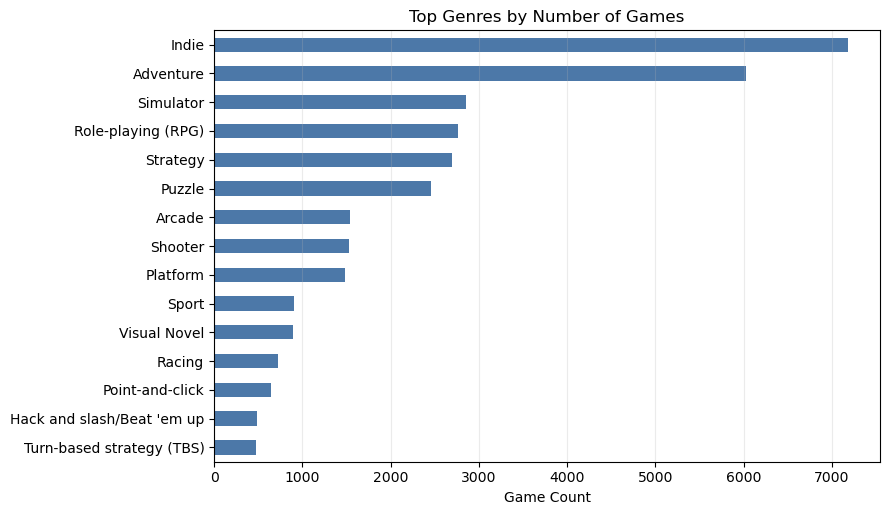

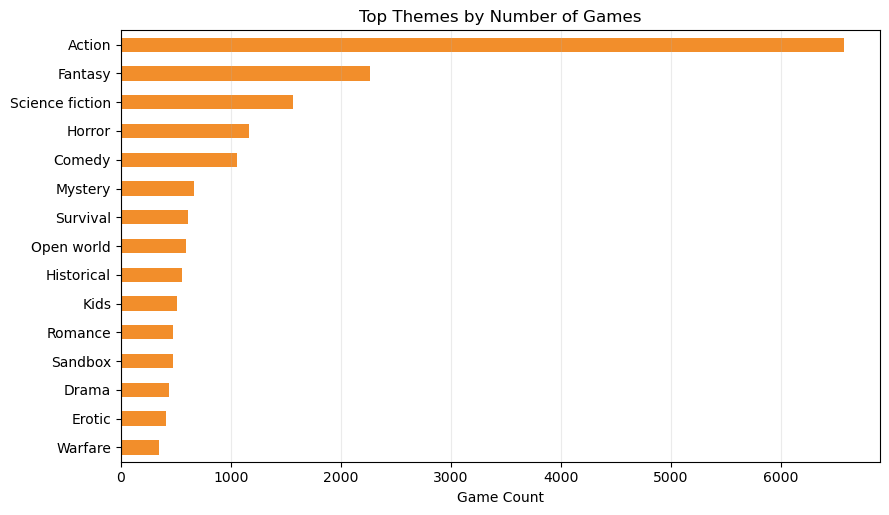

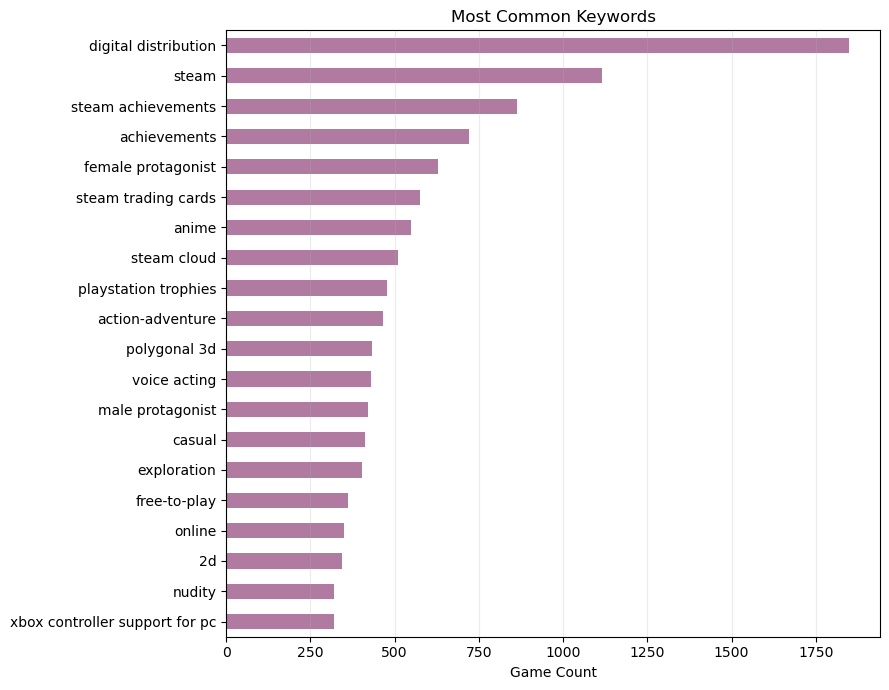

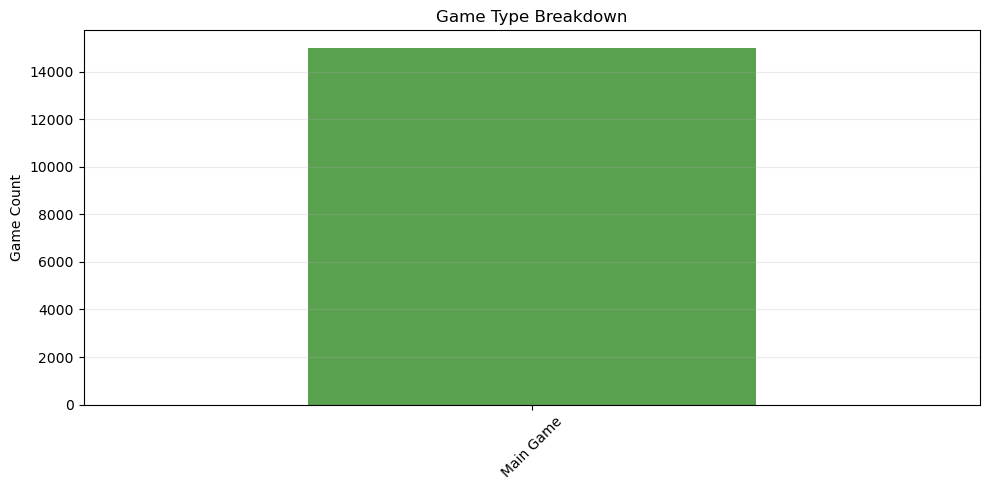

In [7]:
plot_barh(top_genres, 'genre_name', 'game_count', 'Top Genres by Number of Games', top_n=15)
plot_barh(top_themes, 'theme_name', 'game_count', 'Top Themes by Number of Games', top_n=15, color='#F28E2B')
plot_barh(top_keywords, 'keyword_name', 'game_count', 'Most Common Keywords', top_n=20, color='#B07AA1')
plot_bar(game_type_breakdown, 'game_type', 'game_count', 'Game Type Breakdown', color='#59A14F')

# 4. Platform Coverage

These queries answer where games in the project catalog can be played. Platform counts are relationship-based, so totals across platform bars should not be summed as unique games.

In [8]:
top_platforms = run_query('''
SELECT
    p.name AS platform_name,
    COALESCE(p.abbreviation, '') AS platform_abbreviation,
    COUNT(DISTINCT g.game_id) AS game_count
FROM games g
JOIN game_platforms gp
    ON g.game_id = gp.game_id
JOIN platforms p
    ON gp.platform_id = p.platform_id
GROUP BY p.name, p.abbreviation
ORDER BY game_count DESC, p.name;
''')

platform_family_distribution = run_query('''
SELECT
    COALESCE(pf.name, 'Unknown / No Family') AS platform_family,
    COUNT(DISTINCT g.game_id) AS game_count
FROM games g
JOIN game_platforms gp
    ON g.game_id = gp.game_id
JOIN platforms p
    ON gp.platform_id = p.platform_id
LEFT JOIN platform_families pf
    ON p.platform_family_id = pf.platform_family_id
GROUP BY COALESCE(pf.name, 'Unknown / No Family')
ORDER BY game_count DESC, platform_family;
''')

platform_type_distribution = run_query('''
SELECT
    COALESCE(pt.name, 'Unknown / No Type') AS platform_type,
    COUNT(DISTINCT g.game_id) AS game_count
FROM games g
JOIN game_platforms gp
    ON g.game_id = gp.game_id
JOIN platforms p
    ON gp.platform_id = p.platform_id
LEFT JOIN platform_types pt
    ON p.platform_type_id = pt.platform_type_id
GROUP BY COALESCE(pt.name, 'Unknown / No Type')
ORDER BY game_count DESC, platform_type;
''')

tables_to_export.update({
    'top_platforms': top_platforms,
    'platform_family_distribution': platform_family_distribution,
    'platform_type_distribution': platform_type_distribution,
})

display(top_platforms.head(25))
display(platform_family_distribution)
display(platform_type_distribution)

,platform_name,platform_abbreviation,game_count
0,PC (Microsoft Windows),PC,10735
1,Mac,Mac,3027
2,iOS,iOS,2608
3,PlayStation 4,PS4,2502
4,Nintendo Switch,Switch,2342
5,Android,Android,2204
6,Xbox One,XONE,2161
7,Linux,Linux,2018
8,PlayStation 5,PS5,1159
9,Xbox Series X|S,Series X|S,1041


,platform_family,game_count
0,Unknown / No Family,13162
1,Linux,3969
2,PlayStation,3682
3,Nintendo,3248
4,Xbox,2955
5,Sega,23


,platform_type,game_count
0,Operating_system,12441
1,Console,4778
2,Portable_console,1212
3,Platform,1129
4,Unknown / No Type,200
5,Arcade,85
6,Computer,34


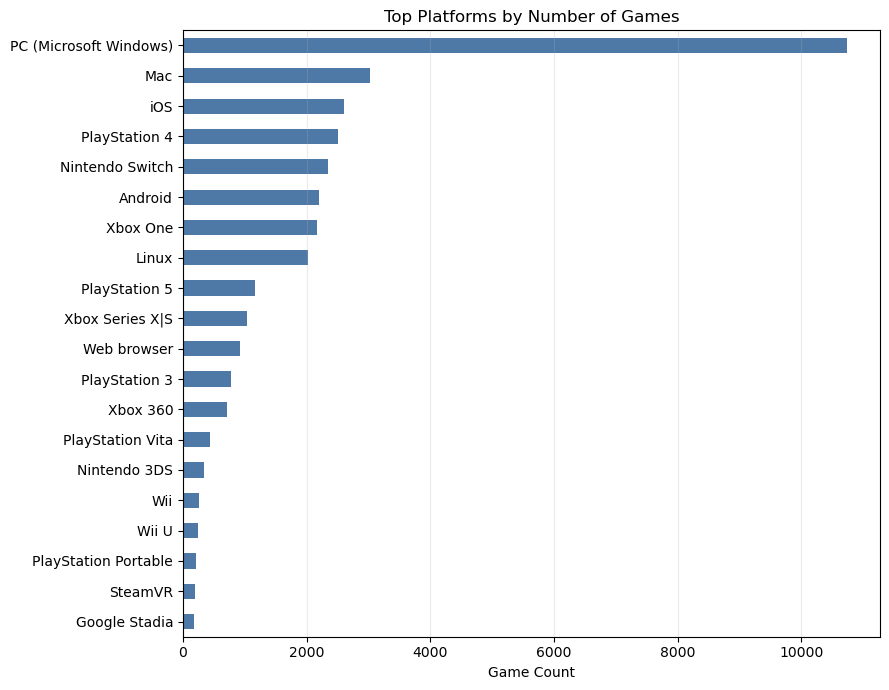

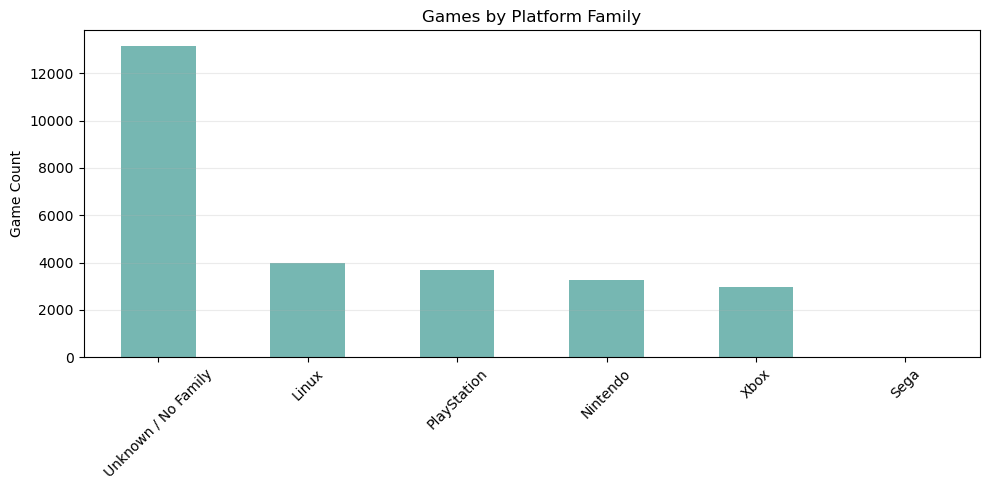

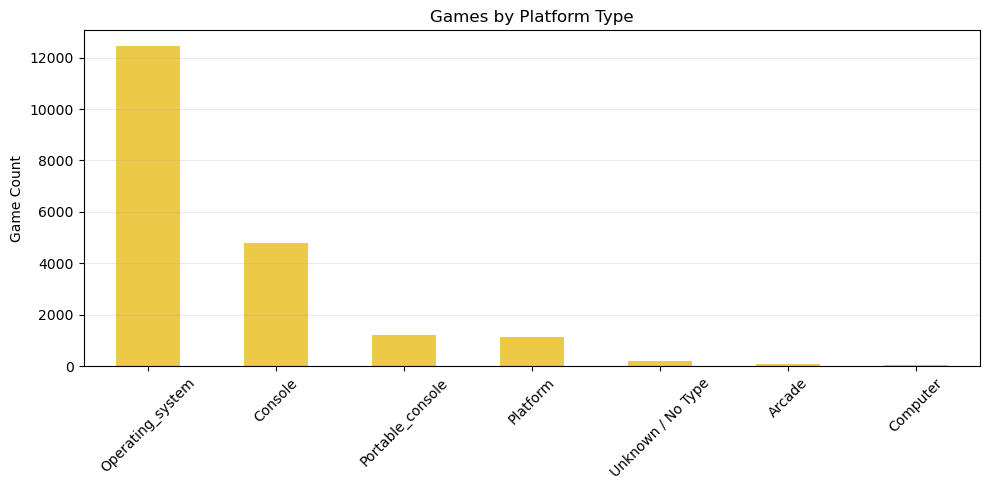

In [9]:
plot_barh(top_platforms, 'platform_name', 'game_count', 'Top Platforms by Number of Games', top_n=20, color='#4E79A7')
plot_bar(platform_family_distribution, 'platform_family', 'game_count', 'Games by Platform Family', color='#76B7B2')
plot_bar(platform_type_distribution, 'platform_type', 'game_count', 'Games by Platform Type', color='#EDC948')

# 5. Release Timeline

The year-level charts use `games.release_year` for game-level first-release trends. Platform-specific release timing should use `release_dates` and should be interpreted separately.

In [10]:
games_by_release_year = run_query('''
SELECT
    release_year,
    COUNT(DISTINCT game_id) AS game_count
FROM games
WHERE release_year IS NOT NULL
GROUP BY release_year
ORDER BY release_year;
''')

games_by_release_decade = run_query('''
WITH decade_bins AS (
    SELECT
        game_id,
        CASE
            WHEN release_year IS NULL THEN 'Unknown'
            WHEN release_year < 1980 THEN 'Before 1980'
            WHEN release_year BETWEEN 1980 AND 1989 THEN '1980s'
            WHEN release_year BETWEEN 1990 AND 1999 THEN '1990s'
            WHEN release_year BETWEEN 2000 AND 2009 THEN '2000s'
            WHEN release_year BETWEEN 2010 AND 2019 THEN '2010s'
            WHEN release_year BETWEEN 2020 AND 2029 THEN '2020s'
            ELSE 'Future / Other'
        END AS release_decade,
        CASE
            WHEN release_year IS NULL THEN 99
            WHEN release_year < 1980 THEN 1
            WHEN release_year BETWEEN 1980 AND 1989 THEN 2
            WHEN release_year BETWEEN 1990 AND 1999 THEN 3
            WHEN release_year BETWEEN 2000 AND 2009 THEN 4
            WHEN release_year BETWEEN 2010 AND 2019 THEN 5
            WHEN release_year BETWEEN 2020 AND 2029 THEN 6
            ELSE 7
        END AS sort_order
    FROM games
)
SELECT
    release_decade,
    COUNT(DISTINCT game_id) AS game_count
FROM decade_bins
GROUP BY release_decade, sort_order
ORDER BY sort_order;
''')

release_decade_by_platform_type = run_query('''
WITH game_decades AS (
    SELECT
        game_id,
        CASE
            WHEN release_year IS NULL THEN 'Unknown'
            WHEN release_year < 1980 THEN 'Before 1980'
            WHEN release_year BETWEEN 1980 AND 1989 THEN '1980s'
            WHEN release_year BETWEEN 1990 AND 1999 THEN '1990s'
            WHEN release_year BETWEEN 2000 AND 2009 THEN '2000s'
            WHEN release_year BETWEEN 2010 AND 2019 THEN '2010s'
            WHEN release_year BETWEEN 2020 AND 2029 THEN '2020s'
            ELSE 'Future / Other'
        END AS release_decade,
        CASE
            WHEN release_year IS NULL THEN 99
            WHEN release_year < 1980 THEN 1
            WHEN release_year BETWEEN 1980 AND 1989 THEN 2
            WHEN release_year BETWEEN 1990 AND 1999 THEN 3
            WHEN release_year BETWEEN 2000 AND 2009 THEN 4
            WHEN release_year BETWEEN 2010 AND 2019 THEN 5
            WHEN release_year BETWEEN 2020 AND 2029 THEN 6
            ELSE 7
        END AS sort_order
    FROM games
)
SELECT
    gd.release_decade,
    gd.sort_order,
    COALESCE(pt.name, 'Unknown / No Type') AS platform_type,
    COUNT(DISTINCT gd.game_id) AS game_count
FROM game_decades gd
JOIN game_platforms gp
    ON gd.game_id = gp.game_id
JOIN platforms p
    ON gp.platform_id = p.platform_id
LEFT JOIN platform_types pt
    ON p.platform_type_id = pt.platform_type_id
GROUP BY gd.release_decade, gd.sort_order, COALESCE(pt.name, 'Unknown / No Type')
ORDER BY gd.sort_order, platform_type;
''')

tables_to_export.update({
    'games_by_release_year': games_by_release_year,
    'games_by_release_decade': games_by_release_decade,
    'release_decade_by_platform_type': release_decade_by_platform_type,
})

display(games_by_release_year.head())
display(games_by_release_year.tail())
display(games_by_release_decade)
display(release_decade_by_platform_type.head(30))

,release_year,game_count
0,2010,1000
1,2011,1000
2,2012,1000
3,2013,1000
4,2014,1000


,release_year,game_count
10,2020,1000
11,2021,1000
12,2022,1000
13,2023,1000
14,2024,1000


,release_decade,game_count
0,2010s,10000
1,2020s,5000


,release_decade,sort_order,platform_type,game_count
0,2010s,5,Arcade,76
1,2010s,5,Computer,19
2,2010s,5,Console,3082
3,2010s,5,Operating_system,8016
4,2010s,5,Platform,836
5,2010s,5,Portable_console,1148
6,2010s,5,Unknown / No Type,108
7,2020s,6,Arcade,9
8,2020s,6,Computer,15
9,2020s,6,Console,1696


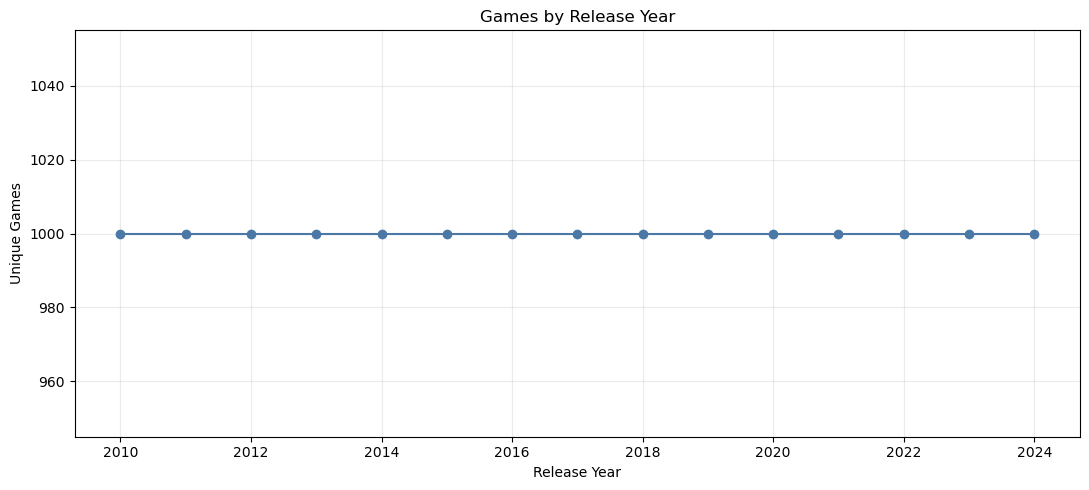

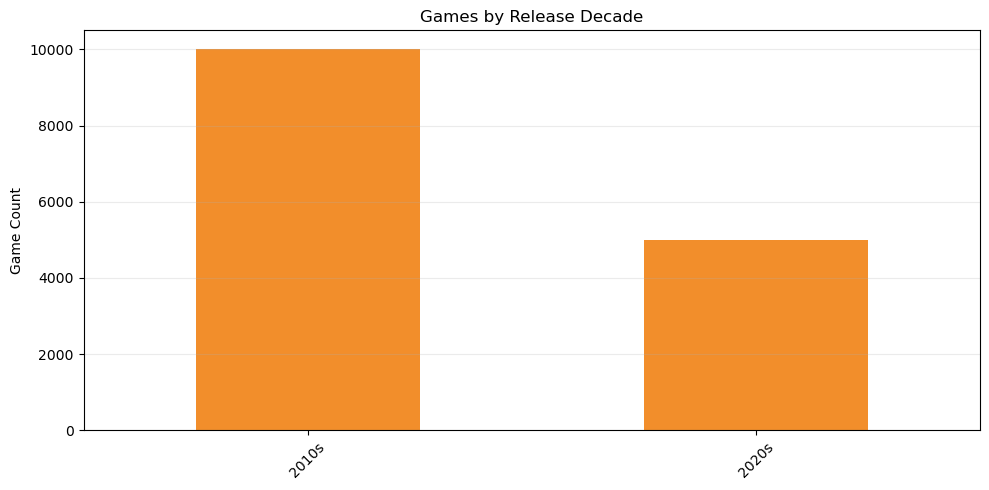

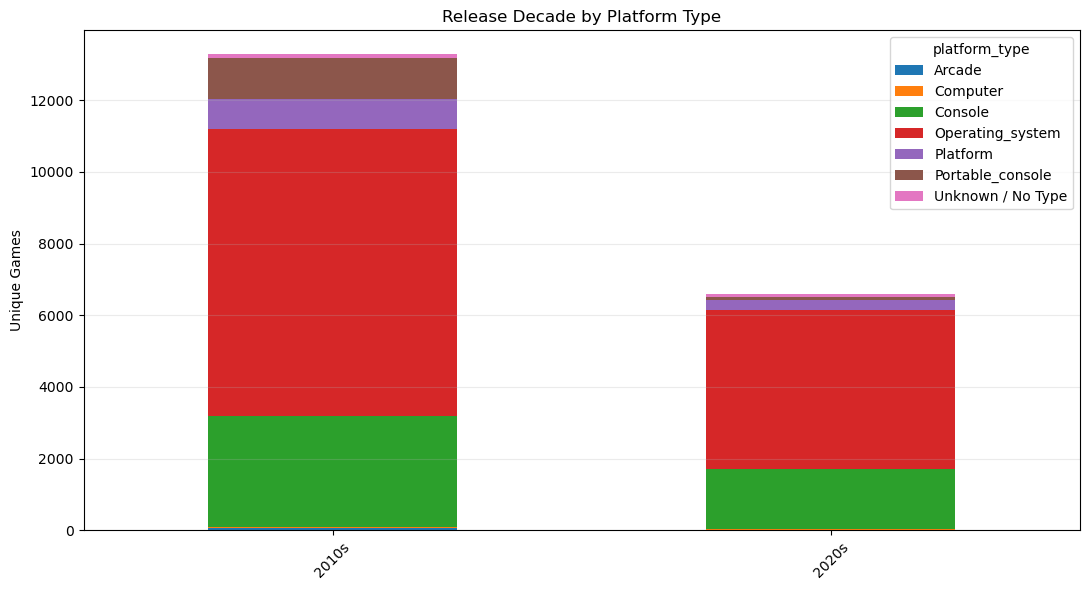

In [11]:
if not games_by_release_year.empty:
    ax = games_by_release_year.plot.line(x='release_year', y='game_count', marker='o', figsize=(11, 5), legend=False, color='#4C78A8')
    ax.set_title('Games by Release Year')
    ax.set_xlabel('Release Year')
    ax.set_ylabel('Unique Games')
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

plot_bar(games_by_release_decade, 'release_decade', 'game_count', 'Games by Release Decade', color='#F28E2B')

if not release_decade_by_platform_type.empty:
    platform_pivot = release_decade_by_platform_type.pivot_table(
        index='release_decade',
        columns='platform_type',
        values='game_count',
        aggfunc='sum',
        fill_value=0,
    )
    platform_pivot = platform_pivot.reindex(games_by_release_decade['release_decade'])
    ax = platform_pivot.plot(kind='bar', stacked=True, figsize=(11, 6))
    ax.set_title('Release Decade by Platform Type')
    ax.set_xlabel('')
    ax.set_ylabel('Unique Games')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()

# 6. Rating and Popularity Overview

This section describes quality-score coverage, rating bands, rating-count skew, and popularity signal availability. `total_rating_count` is treated as rating evidence/activity, meaning how much rating input exists for a game; it is not a direct visibility measure. Visibility/current interest is described separately through PopScore primitives where available. Popularity primitives are summarized by source/type and are not combined into a single popularity score.

In [12]:
game_base = run_query('''
SELECT
    game_id,
    name,
    release_year,
    rating,
    rating_count,
    aggregated_rating,
    aggregated_rating_count,
    total_rating,
    total_rating_count
FROM games;
''')

rating_bands = run_query('''
SELECT
    CASE
        WHEN total_rating IS NULL THEN 'Unrated / insufficient data'
        WHEN total_rating >= 90 THEN 'Excellent'
        WHEN total_rating >= 80 THEN 'Highly rated'
        WHEN total_rating >= 70 THEN 'Good'
        WHEN total_rating >= 60 THEN 'Mixed / average'
        ELSE 'Lower rated'
    END AS rating_band,
    COUNT(DISTINCT game_id) AS game_count
FROM games
GROUP BY rating_band
ORDER BY
    CASE rating_band
        WHEN 'Excellent' THEN 1
        WHEN 'Highly rated' THEN 2
        WHEN 'Good' THEN 3
        WHEN 'Mixed / average' THEN 4
        WHEN 'Lower rated' THEN 5
        ELSE 6
    END;
''')

rating_coverage = run_query('''
SELECT
    COUNT(*) AS total_games,
    SUM(CASE WHEN total_rating IS NOT NULL THEN 1 ELSE 0 END) AS games_with_total_rating,
    SUM(CASE WHEN total_rating_count IS NOT NULL THEN 1 ELSE 0 END) AS games_with_total_rating_count,
    SUM(CASE WHEN rating IS NOT NULL THEN 1 ELSE 0 END) AS games_with_user_rating,
    SUM(CASE WHEN rating_count IS NOT NULL THEN 1 ELSE 0 END) AS games_with_user_rating_count,
    SUM(CASE WHEN aggregated_rating IS NOT NULL THEN 1 ELSE 0 END) AS games_with_critic_rating,
    SUM(CASE WHEN aggregated_rating_count IS NOT NULL THEN 1 ELSE 0 END) AS games_with_critic_rating_count
FROM games;
''')

popularity_signal_availability = run_query('''
SELECT
    COALESCE(egs.source_name, 'Unknown Source') AS popularity_source,
    COALESCE(pt.name, 'Unknown Popularity Type') AS popularity_type,
    COUNT(DISTINCT pp.game_id) AS games_with_signal,
    COUNT(*) AS signal_records
FROM popularity_primitives pp
LEFT JOIN popularity_types pt
    ON pp.popularity_type_id = pt.popularity_type_id
LEFT JOIN external_game_sources egs
    ON pp.external_popularity_source_id = egs.external_game_source_id
GROUP BY
    COALESCE(egs.source_name, 'Unknown Source'),
    COALESCE(pt.name, 'Unknown Popularity Type')
ORDER BY games_with_signal DESC, signal_records DESC;
''')

tables_to_export.update({
    'game_base_rating_fields': game_base,
    'rating_bands': rating_bands,
    'rating_coverage': rating_coverage,
    'popularity_signal_availability': popularity_signal_availability,
})

display(game_base[['total_rating', 'total_rating_count']].describe())
display(rating_bands)
display(rating_coverage)
display(popularity_signal_availability)

,total_rating,total_rating_count
count,"6,278.00","6,278.00"
mean,70.18,77.64
std,12.67,257.24
min,0.00,0.00
25%,64.00,3.00
50%,71.77,16.00
75%,79.32,48.00
max,99.73,"5,805.00"


,rating_band,game_count
0,Excellent,178
1,Highly rated,1241
2,Good,2522
3,Mixed / average,1295
4,Lower rated,1042
5,Unrated / insufficient data,8722


,total_games,games_with_total_rating,games_with_total_rating_count,games_with_user_rating,games_with_user_rating_count,games_with_critic_rating,games_with_critic_rating_count
0,15000,6278,6278,5993,5993,3839,3839


,popularity_source,popularity_type,games_with_signal,signal_records
0,IGDB,Played,7949,7949
1,Steam,Negative Reviews,7473,7473
2,Steam,Total Reviews,7462,7462
3,Steam,Postitive Reviews,7462,7462
4,Steam,24hr Peak Players,7462,7462
5,IGDB,Want to Play,7267,7267
6,IGDB,Playing,5102,5102
7,IGDB,Visits,5027,5027
8,Twitch,24hr Hours Watched,3415,3415
9,Steam,Global Top Sellers,1821,1821


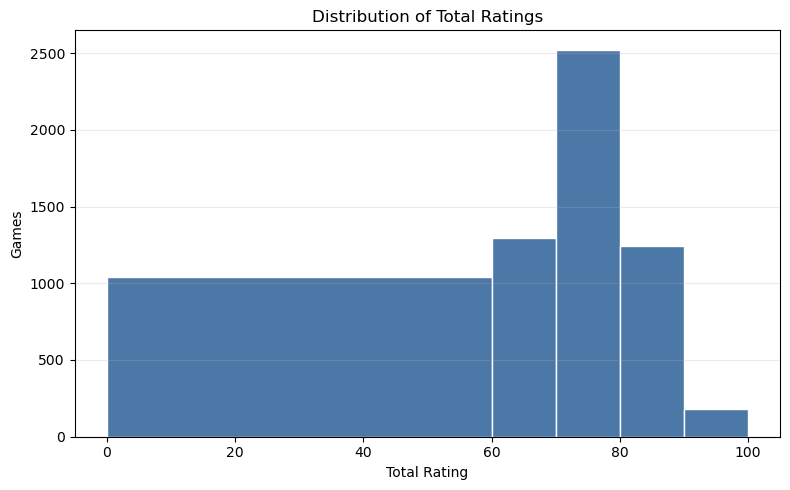

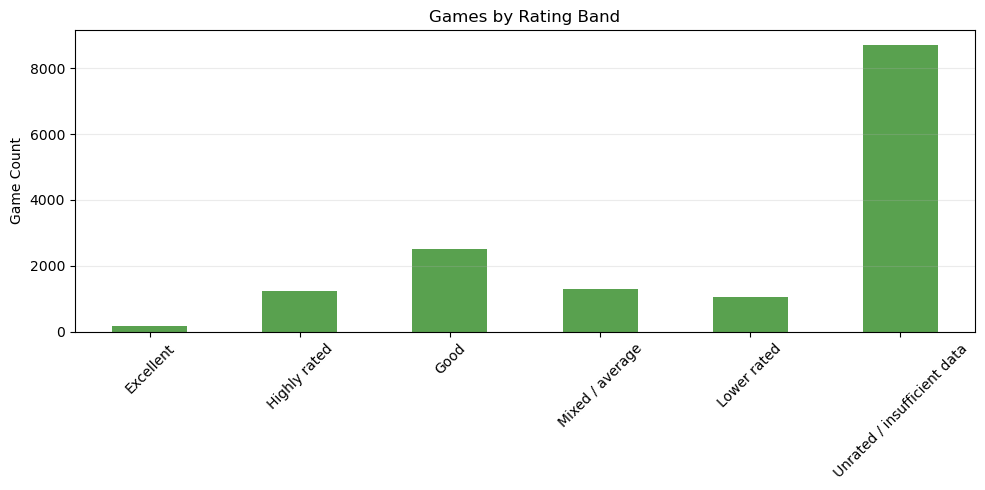

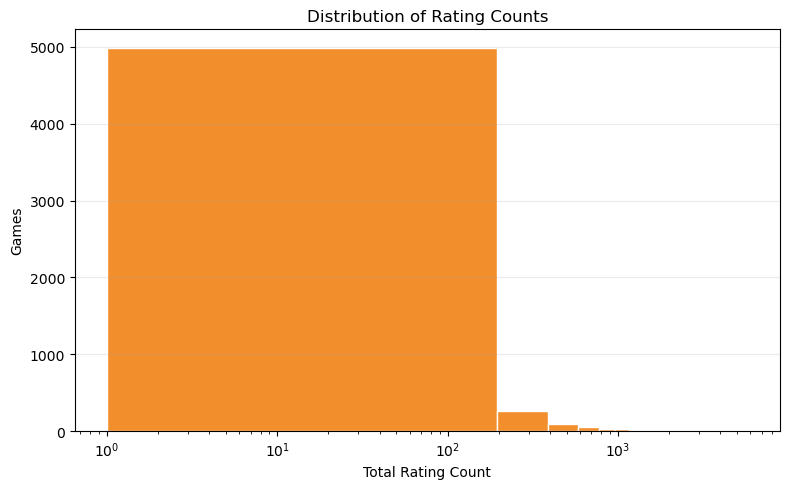

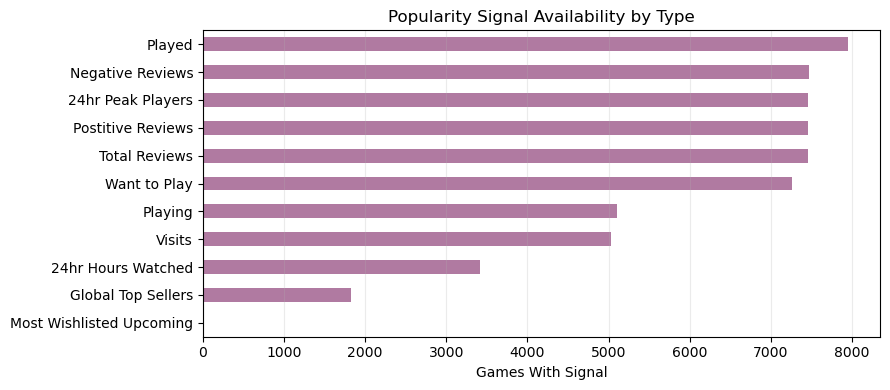

In [13]:
rating_values = game_base['total_rating'].dropna()
if not rating_values.empty:
    ax = rating_values.plot.hist(bins=[0, 60, 70, 80, 90, 100], figsize=(8, 5), color='#4C78A8', edgecolor='white')
    ax.set_title('Distribution of Total Ratings')
    ax.set_xlabel('Total Rating')
    ax.set_ylabel('Games')
    ax.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()

plot_bar(rating_bands, 'rating_band', 'game_count', 'Games by Rating Band', color='#59A14F')

rating_counts = game_base['total_rating_count'].dropna()
if not rating_counts.empty:
    positive_counts = rating_counts[rating_counts > 0]
    ax = positive_counts.plot.hist(bins=30, figsize=(8, 5), color='#F28E2B', edgecolor='white')
    ax.set_title('Distribution of Rating Counts')
    ax.set_xlabel('Total Rating Count')
    ax.set_ylabel('Games')
    if positive_counts.max() > 0:
        ax.set_xscale('log')
    ax.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()

plot_barh(popularity_signal_availability, 'popularity_type', 'games_with_signal', 'Popularity Signal Availability by Type', top_n=20, color='#B07AA1')

# 7. Developer and Publisher Overview

Developer and publisher analysis uses role flags in `involved_companies`. Do not treat every involved company as a developer or publisher.

In [14]:
top_developers = run_query('''
SELECT
    c.name AS developer_name,
    COUNT(DISTINCT ic.game_id) AS game_count
FROM involved_companies ic
JOIN companies c
    ON ic.company_id = c.company_id
WHERE ic.developer = 1
GROUP BY c.name
ORDER BY game_count DESC, c.name
LIMIT 25;
''')

top_publishers = run_query('''
SELECT
    c.name AS publisher_name,
    COUNT(DISTINCT ic.game_id) AS game_count
FROM involved_companies ic
JOIN companies c
    ON ic.company_id = c.company_id
WHERE ic.publisher = 1
GROUP BY c.name
ORDER BY game_count DESC, c.name
LIMIT 25;
''')

company_role_coverage = run_query('''
SELECT 'Developer' AS role_name,
       COUNT(*) AS relationship_count,
       COUNT(DISTINCT game_id) AS game_count
FROM involved_companies
WHERE developer = 1

UNION ALL
SELECT 'Publisher',
       COUNT(*),
       COUNT(DISTINCT game_id)
FROM involved_companies
WHERE publisher = 1

UNION ALL
SELECT 'Porting',
       COUNT(*),
       COUNT(DISTINCT game_id)
FROM involved_companies
WHERE porting = 1

UNION ALL
SELECT 'Supporting',
       COUNT(*),
       COUNT(DISTINCT game_id)
FROM involved_companies
WHERE supporting = 1;
''')

tables_to_export.update({
    'top_developers': top_developers,
    'top_publishers': top_publishers,
    'company_role_coverage': company_role_coverage,
})

display(top_developers)
display(top_publishers)
display(company_role_coverage)

,developer_name,game_count
0,Capcom,36
1,Gameloft,35
2,Otomate,29
3,Konami,27
4,Nintendo,25
5,Omega Force,24
6,Ubisoft Montreal,24
7,EA Canada,22
8,Spike Chunsoft,21
9,Visual Concepts,21


,publisher_name,game_count
0,Nintendo,212
1,Square Enix,132
2,Ubisoft Entertainment,128
3,Sega,114
4,Bandai Namco Entertainment,112
5,Electronic Arts,101
6,Sony Computer Entertainment,86
7,Activision,75
8,Devolver Digital,75
9,Focus Entertainment,69


,role_name,relationship_count,game_count
0,Developer,10919,10011
1,Publisher,11764,9745
2,Porting,514,450
3,Supporting,743,451


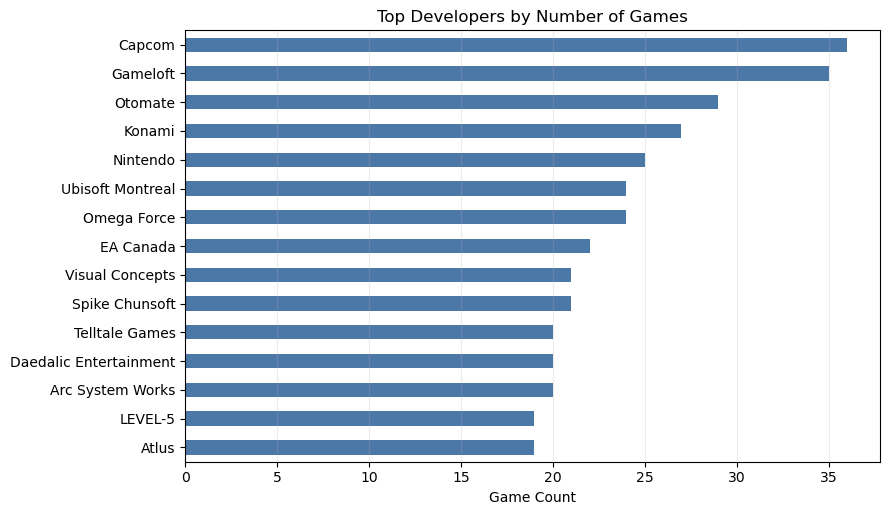

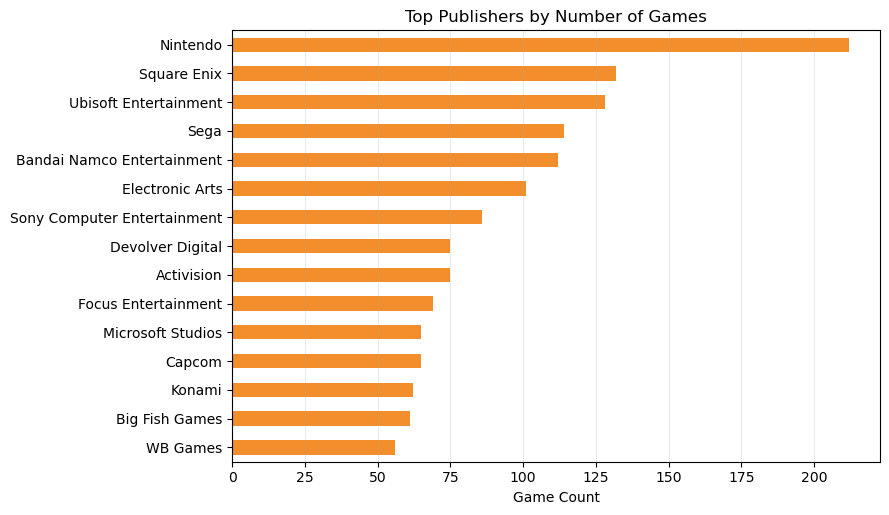

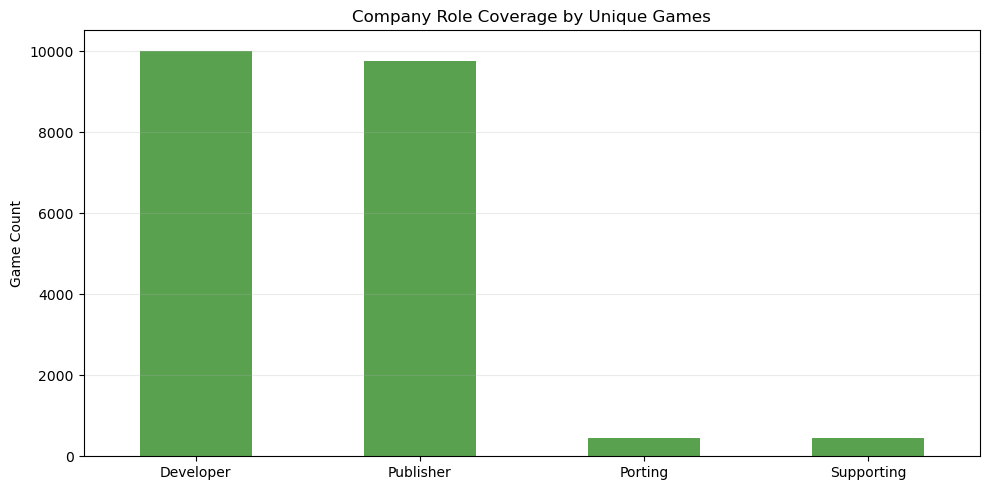

In [15]:
plot_barh(top_developers, 'developer_name', 'game_count', 'Top Developers by Number of Games', top_n=15, color='#4C78A8')
plot_barh(top_publishers, 'publisher_name', 'game_count', 'Top Publishers by Number of Games', top_n=15, color='#F28E2B')
plot_bar(company_role_coverage, 'role_name', 'game_count', 'Company Role Coverage by Unique Games', color='#59A14F', rotation=0)

# 8. Metadata Completeness and Data Quality

This section documents which fields and relationships are complete enough for later diagnostic, predictive, recommendation, and RAG work.

In [16]:
field_completeness_sql = '''
SELECT
    game_id,
    name,
    summary,
    storyline,
    first_release_date,
    first_release_date_iso,
    release_year,
    rating,
    rating_count,
    aggregated_rating,
    aggregated_rating_count,
    total_rating,
    total_rating_count,
    game_type_id,
    game_status_id,
    cover_id,
    updated_at_iso
FROM games;
'''
field_source = run_query(field_completeness_sql)

field_rows = []
text_fields = {'name', 'summary', 'storyline', 'first_release_date_iso', 'updated_at_iso'}
for column in field_source.columns:
    if column == 'game_id':
        continue
    if column in text_fields:
        non_null_count = field_source[column].fillna('').astype(str).str.strip().ne('').sum()
    else:
        non_null_count = field_source[column].notna().sum()
    total_records = len(field_source)
    field_rows.append({
        'field_name': column,
        'total_records': total_records,
        'non_null_count': int(non_null_count),
        'missing_count': int(total_records - non_null_count),
        'completion_rate': round(100 * non_null_count / total_records, 2) if total_records else 0,
    })

field_completeness = pd.DataFrame(field_rows).sort_values(['completion_rate', 'field_name'], ascending=[True, True])
tables_to_export['field_completeness'] = field_completeness
display(field_completeness)

,field_name,total_records,non_null_count,missing_count,completion_rate
13,game_status_id,15000,1400,13600,9.33
2,storyline,15000,3072,11928,20.48
8,aggregated_rating,15000,3839,11161,25.59
9,aggregated_rating_count,15000,3839,11161,25.59
6,rating,15000,5993,9007,39.95
7,rating_count,15000,5993,9007,39.95
10,total_rating,15000,6278,8722,41.85
11,total_rating_count,15000,6278,8722,41.85
14,cover_id,15000,14446,554,96.31
1,summary,15000,14564,436,97.09


In [17]:
relationship_coverage_wide = run_query('''
WITH
genre_games AS (
    SELECT DISTINCT game_id FROM game_genres
),
theme_games AS (
    SELECT DISTINCT game_id FROM game_themes
),
keyword_games AS (
    SELECT DISTINCT game_id FROM game_keywords
),
platform_games AS (
    SELECT DISTINCT game_id FROM game_platforms
),
company_games AS (
    SELECT DISTINCT game_id FROM involved_companies
),
release_date_games AS (
    SELECT DISTINCT game_id FROM release_dates
),
cover_games AS (
    SELECT DISTINCT game_id FROM covers
),
website_games AS (
    SELECT DISTINCT game_id FROM websites
)
SELECT
    COUNT(DISTINCT g.game_id) AS total_games,
    COUNT(DISTINCT gg.game_id) AS games_with_genre,
    COUNT(DISTINCT tg.game_id) AS games_with_theme,
    COUNT(DISTINCT kg.game_id) AS games_with_keyword,
    COUNT(DISTINCT pg.game_id) AS games_with_platform,
    COUNT(DISTINCT cg.game_id) AS games_with_company,
    COUNT(DISTINCT rdg.game_id) AS games_with_release_date,
    COUNT(DISTINCT cov.game_id) AS games_with_cover,
    COUNT(DISTINCT wg.game_id) AS games_with_website
FROM games g
LEFT JOIN genre_games gg
    ON g.game_id = gg.game_id
LEFT JOIN theme_games tg
    ON g.game_id = tg.game_id
LEFT JOIN keyword_games kg
    ON g.game_id = kg.game_id
LEFT JOIN platform_games pg
    ON g.game_id = pg.game_id
LEFT JOIN company_games cg
    ON g.game_id = cg.game_id
LEFT JOIN release_date_games rdg
    ON g.game_id = rdg.game_id
LEFT JOIN cover_games cov
    ON g.game_id = cov.game_id
LEFT JOIN website_games wg
    ON g.game_id = wg.game_id;
''')

total_games = int(relationship_coverage_wide.loc[0, 'total_games'])
relationship_rows = []
for column in relationship_coverage_wide.columns:
    if column == 'total_games':
        continue
    value = int(relationship_coverage_wide.loc[0, column])
    relationship_rows.append({
        'relationship': column.replace('games_with_', '').replace('_', ' ').title(),
        'games_with_relationship': value,
        'total_games': total_games,
        'coverage_rate': round(100 * value / total_games, 2) if total_games else 0,
    })

relationship_coverage = pd.DataFrame(relationship_rows).sort_values('coverage_rate')
tables_to_export['relationship_coverage'] = relationship_coverage
display(relationship_coverage)

,relationship,games_with_relationship,total_games,coverage_rate
2,Keyword,8903,15000,59.35
4,Company,10608,15000,70.72
1,Theme,10817,15000,72.11
6,Cover,14446,15000,96.31
7,Website,14650,15000,97.67
0,Genre,15000,15000,100.00
3,Platform,15000,15000,100.00
5,Release Date,15000,15000,100.00


In [18]:
def scalar(sql):
    return run_query(sql).iloc[0, 0]


dq_rows = []
dq_rows.append({
    'check_name': 'SQLite integrity check',
    'expected_result': 'ok',
    'actual_result': str(integrity_check.iloc[0, 0]),
    'failing_rows': 0 if str(integrity_check.iloc[0, 0]).lower() == 'ok' else 1,
})
dq_rows.append({
    'check_name': 'Foreign key failures',
    'expected_result': '0',
    'actual_result': str(len(foreign_key_check)),
    'failing_rows': len(foreign_key_check),
})
dq_rows.append({
    'check_name': 'Empty core tables',
    'expected_result': '0',
    'actual_result': str(scalar('''
        SELECT COUNT(*)
        FROM (
            SELECT 'games' AS table_name, COUNT(*) AS row_count FROM games
            UNION ALL SELECT 'genres', COUNT(*) FROM genres
            UNION ALL SELECT 'themes', COUNT(*) FROM themes
            UNION ALL SELECT 'platforms', COUNT(*) FROM platforms
            UNION ALL SELECT 'game_genres', COUNT(*) FROM game_genres
            UNION ALL SELECT 'game_platforms', COUNT(*) FROM game_platforms
        )
        WHERE row_count = 0;
    ''')),
    'failing_rows': int(scalar('''
        SELECT COUNT(*)
        FROM (
            SELECT 'games' AS table_name, COUNT(*) AS row_count FROM games
            UNION ALL SELECT 'genres', COUNT(*) FROM genres
            UNION ALL SELECT 'themes', COUNT(*) FROM themes
            UNION ALL SELECT 'platforms', COUNT(*) FROM platforms
            UNION ALL SELECT 'game_genres', COUNT(*) FROM game_genres
            UNION ALL SELECT 'game_platforms', COUNT(*) FROM game_platforms
        )
        WHERE row_count = 0;
    ''')),
})

dq_sql_checks = {
    'Missing required game names': '''
        SELECT COUNT(*) FROM games
        WHERE name IS NULL OR TRIM(name) = '';
    ''',
    'Invalid rating ranges': '''
        SELECT COUNT(*) FROM games
        WHERE (rating IS NOT NULL AND (rating < 0 OR rating > 100))
           OR (aggregated_rating IS NOT NULL AND (aggregated_rating < 0 OR aggregated_rating > 100))
           OR (total_rating IS NOT NULL AND (total_rating < 0 OR total_rating > 100));
    ''',
    'Negative rating counts': '''
        SELECT COUNT(*) FROM games
        WHERE (rating_count IS NOT NULL AND rating_count < 0)
           OR (aggregated_rating_count IS NOT NULL AND aggregated_rating_count < 0)
           OR (total_rating_count IS NOT NULL AND total_rating_count < 0);
    ''',
    'Invalid release months': '''
        SELECT COUNT(*) FROM release_dates
        WHERE release_month IS NOT NULL
          AND (release_month < 1 OR release_month > 12);
    ''',
    'Invalid release days': '''
        SELECT COUNT(*) FROM release_dates
        WHERE release_day IS NOT NULL
          AND (release_day < 1 OR release_day > 31);
    ''',
    'Duplicate game-genre relationships': '''
        SELECT COUNT(*) FROM (
            SELECT game_id, genre_id
            FROM game_genres
            GROUP BY game_id, genre_id
            HAVING COUNT(*) > 1
        );
    ''',
    'Duplicate game-theme relationships': '''
        SELECT COUNT(*) FROM (
            SELECT game_id, theme_id
            FROM game_themes
            GROUP BY game_id, theme_id
            HAVING COUNT(*) > 1
        );
    ''',
    'Duplicate game-keyword relationships': '''
        SELECT COUNT(*) FROM (
            SELECT game_id, keyword_id
            FROM game_keywords
            GROUP BY game_id, keyword_id
            HAVING COUNT(*) > 1
        );
    ''',
    'Duplicate game-platform relationships': '''
        SELECT COUNT(*) FROM (
            SELECT game_id, platform_id
            FROM game_platforms
            GROUP BY game_id, platform_id
            HAVING COUNT(*) > 1
        );
    ''',
}

for check_name, sql in dq_sql_checks.items():
    failing_rows = int(scalar(sql))
    dq_rows.append({
        'check_name': check_name,
        'expected_result': '0',
        'actual_result': str(failing_rows),
        'failing_rows': failing_rows,
    })

dq_status_cards = pd.DataFrame(dq_rows)
dq_status_cards['status'] = dq_status_cards['failing_rows'].apply(lambda x: 'PASS' if x == 0 else 'REVIEW')
tables_to_export['dq_status_cards'] = dq_status_cards
display(dq_status_cards)

,check_name,expected_result,actual_result,failing_rows,status
0,SQLite integrity check,ok,ok,0,PASS
1,Foreign key failures,0,0,0,PASS
2,Empty core tables,0,0,0,PASS
3,Missing required game names,0,0,0,PASS
4,Invalid rating ranges,0,0,0,PASS
5,Negative rating counts,0,0,0,PASS
6,Invalid release months,0,0,0,PASS
7,Invalid release days,0,0,0,PASS
8,Duplicate game-genre relationships,0,0,0,PASS
9,Duplicate game-theme relationships,0,0,0,PASS


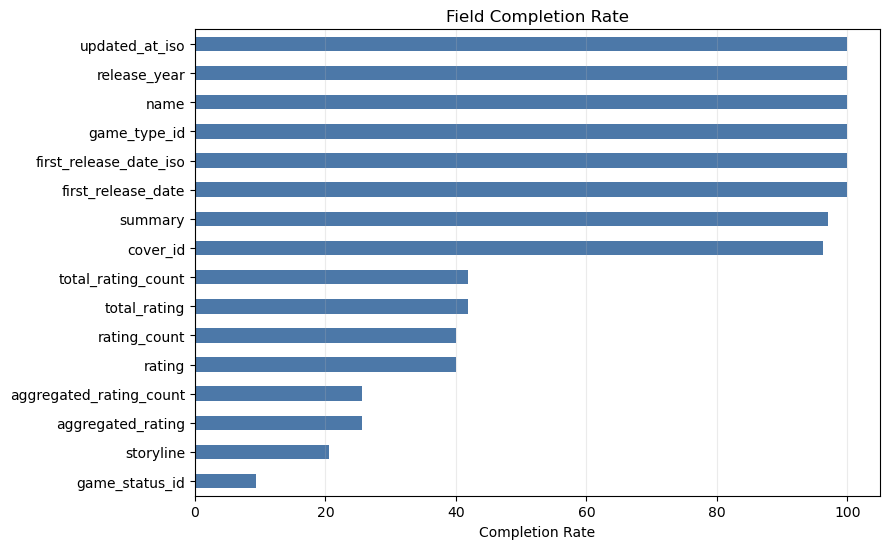

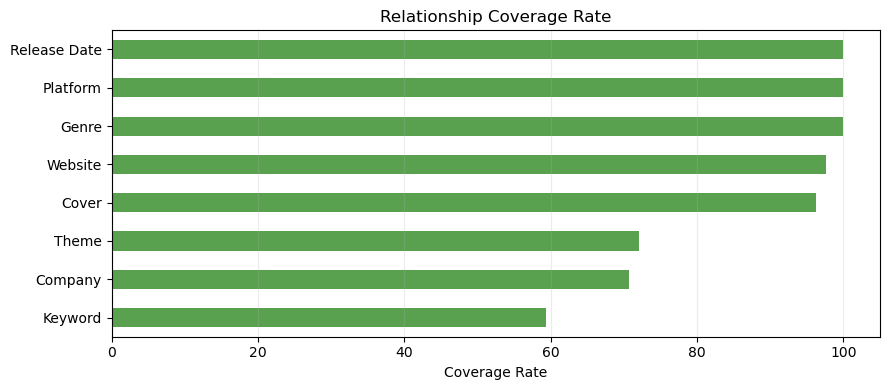

In [19]:
plot_barh(field_completeness.sort_values('completion_rate'), 'field_name', 'completion_rate', 'Field Completion Rate', top_n=len(field_completeness), color='#4C78A8')
plot_barh(relationship_coverage.sort_values('coverage_rate'), 'relationship', 'coverage_rate', 'Relationship Coverage Rate', top_n=len(relationship_coverage), color='#59A14F')

# Optional Add-On: Game Mode and Player Support

This section summarizes play-style metadata such as single-player, multiplayer, co-op, split-screen, and available max-player counts.

Interpretation caveats:

- Game mode counts are not mutually exclusive. A game can be both single-player and multiplayer, so do not use a pie chart or sum the bars as unique games.
- Detailed multiplayer records can be platform-specific, so player support may vary by platform.
- Missing multiplayer detail should be treated as unknown, not as proof that a game is single-player only.
- Max-player fields can contain large online multiplayer outliers, so binned player-count charts are easier to interpret than raw max values.

In [20]:
game_mode_distribution = run_query('''
SELECT
    gm.name AS game_mode,
    COUNT(DISTINCT gmb.game_id) AS game_count
FROM game_modes_bridge gmb
JOIN game_modes gm
    ON gmb.game_mode_id = gm.game_mode_id
GROUP BY gm.name
ORDER BY game_count DESC, gm.name;
''')

multiplayer_by_game = run_query('''
SELECT
    g.game_id,
    g.name,
    CASE WHEN mbg.game_id IS NOT NULL THEN 1 ELSE 0 END AS has_multiplayer_detail,
    COALESCE(mbg.has_campaign_coop, 0) AS has_campaign_coop,
    COALESCE(mbg.has_drop_in, 0) AS has_drop_in,
    COALESCE(mbg.has_lan_coop, 0) AS has_lan_coop,
    COALESCE(mbg.has_offline_coop, 0) AS has_offline_coop,
    COALESCE(mbg.has_online_coop, 0) AS has_online_coop,
    COALESCE(mbg.has_split_screen, 0) AS has_split_screen,
    COALESCE(mbg.max_offline_players, 0) AS max_offline_players,
    COALESCE(mbg.max_online_players, 0) AS max_online_players
FROM games g
LEFT JOIN (
    SELECT
        game_id,
        MAX(CASE WHEN campaign_coop = 1 THEN 1 ELSE 0 END) AS has_campaign_coop,
        MAX(CASE WHEN drop_in = 1 THEN 1 ELSE 0 END) AS has_drop_in,
        MAX(CASE WHEN lan_coop = 1 THEN 1 ELSE 0 END) AS has_lan_coop,
        MAX(CASE WHEN offline_coop = 1 THEN 1 ELSE 0 END) AS has_offline_coop,
        MAX(CASE WHEN online_coop = 1 THEN 1 ELSE 0 END) AS has_online_coop,
        MAX(CASE WHEN split_screen = 1 THEN 1 ELSE 0 END) AS has_split_screen,
        MAX(CASE WHEN COALESCE(offline_coop_max, 0) >= COALESCE(offline_max, 0) THEN COALESCE(offline_coop_max, 0) ELSE COALESCE(offline_max, 0) END) AS max_offline_players,
        MAX(CASE WHEN COALESCE(online_coop_max, 0) >= COALESCE(online_max, 0) THEN COALESCE(online_coop_max, 0) ELSE COALESCE(online_max, 0) END) AS max_online_players
    FROM multiplayer_modes
    GROUP BY game_id
) mbg
    ON g.game_id = mbg.game_id;
''')

total_games = int(kpi_snapshot.loc[kpi_snapshot['kpi'] == 'Total Games', 'value'].iloc[0])
coverage_metrics = [
    ('Games with game mode labels', int(run_query('SELECT COUNT(DISTINCT game_id) AS n FROM game_modes_bridge').iloc[0, 0])),
    ('Games with detailed multiplayer records', int(multiplayer_by_game['has_multiplayer_detail'].sum())),
    ('Games with campaign co-op', int(multiplayer_by_game['has_campaign_coop'].sum())),
    ('Games with drop-in multiplayer', int(multiplayer_by_game['has_drop_in'].sum())),
    ('Games with LAN co-op', int(multiplayer_by_game['has_lan_coop'].sum())),
    ('Games with offline/local co-op', int(multiplayer_by_game['has_offline_coop'].sum())),
    ('Games with online co-op', int(multiplayer_by_game['has_online_coop'].sum())),
    ('Games with split-screen', int(multiplayer_by_game['has_split_screen'].sum())),
    ('Games with offline player max above 0', int((multiplayer_by_game['max_offline_players'] > 0).sum())),
    ('Games with online player max above 0', int((multiplayer_by_game['max_online_players'] > 0).sum())),
]
multiplayer_support_coverage = pd.DataFrame([
    {
        'metric': metric,
        'game_count': game_count,
        'total_games': total_games,
        'pct_of_games': round(100 * game_count / total_games, 2) if total_games else 0,
    }
    for metric, game_count in coverage_metrics
])

player_count_long = []
for count_type, column in [
    ('Offline / local max players', 'max_offline_players'),
    ('Online max players', 'max_online_players'),
]:
    for max_players in multiplayer_by_game.loc[multiplayer_by_game[column] > 0, column]:
        if max_players == 1:
            band = '1 player'
        elif max_players == 2:
            band = '2 players'
        elif max_players <= 4:
            band = '3-4 players'
        elif max_players <= 8:
            band = '5-8 players'
        elif max_players <= 16:
            band = '9-16 players'
        else:
            band = '17+ players'
        player_count_long.append({'player_count_type': count_type, 'player_count_band': band})

player_count_distribution = (
    pd.DataFrame(player_count_long)
    .value_counts(['player_count_type', 'player_count_band'])
    .reset_index(name='game_count')
    if player_count_long else pd.DataFrame(columns=['player_count_type', 'player_count_band', 'game_count'])
)
band_order = ['1 player', '2 players', '3-4 players', '5-8 players', '9-16 players', '17+ players']
player_count_distribution['sort_order'] = player_count_distribution['player_count_band'].map({band: idx for idx, band in enumerate(band_order)})
player_count_distribution = player_count_distribution.sort_values(['player_count_type', 'sort_order']).drop(columns='sort_order')

tables_to_export.update({
    'game_mode_distribution': game_mode_distribution,
    'multiplayer_by_game': multiplayer_by_game,
    'multiplayer_support_coverage': multiplayer_support_coverage,
    'player_count_distribution': player_count_distribution,
})

display(game_mode_distribution)
display(multiplayer_support_coverage)
display(player_count_distribution)
display(multiplayer_by_game[['has_multiplayer_detail', 'max_offline_players', 'max_online_players']].describe().T)

,game_mode,game_count
0,Single player,12702
1,Multiplayer,3492
2,Co-operative,1983
3,Massively Multiplayer Online (MMO),410
4,Split screen,377
5,Battle Royale,71


,metric,game_count,total_games,pct_of_games
0,Games with game mode labels,13328,15000,88.85
1,Games with detailed multiplayer records,1836,15000,12.24
2,Games with campaign co-op,537,15000,3.58
3,Games with drop-in multiplayer,397,15000,2.65
4,Games with LAN co-op,165,15000,1.10
5,Games with offline/local co-op,585,15000,3.90
6,Games with online co-op,860,15000,5.73
7,Games with split-screen,235,15000,1.57
8,Games with offline player max above 0,802,15000,5.35
9,Games with online player max above 0,1007,15000,6.71


,player_count_type,player_count_band,game_count
7,Offline / local max players,1 player,91
0,Offline / local max players,2 players,373
2,Offline / local max players,3-4 players,285
8,Offline / local max players,5-8 players,37
11,Offline / local max players,9-16 players,7
9,Offline / local max players,17+ players,9
10,Online max players,1 player,9
3,Online max players,2 players,199
1,Online max players,3-4 players,358
4,Online max players,5-8 players,190


,count,mean,std,min,25%,50%,75%,max
has_multiplayer_detail,"15,000.00",0.12,0.33,0.00,0.00,0.00,0.00,1.00
max_offline_players,"15,000.00","6,668.91","816,496.59",0.00,0.00,0.00,0.00,"99,999,999.00"
max_online_players,"15,000.00",79.76,"8,199.17",0.00,0.00,0.00,0.00,"1,000,000.00"


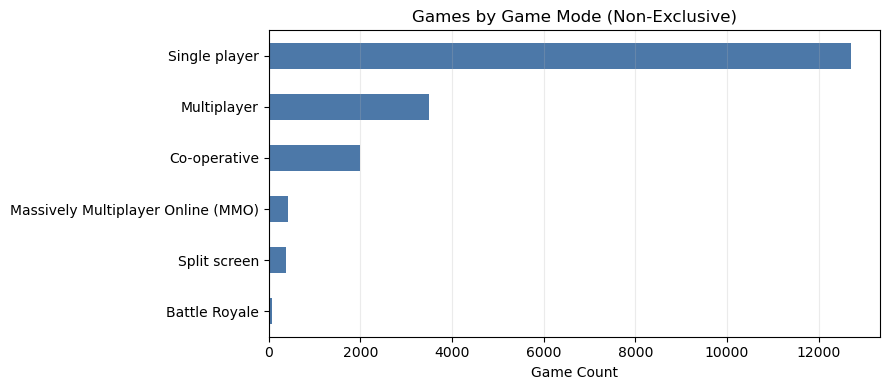

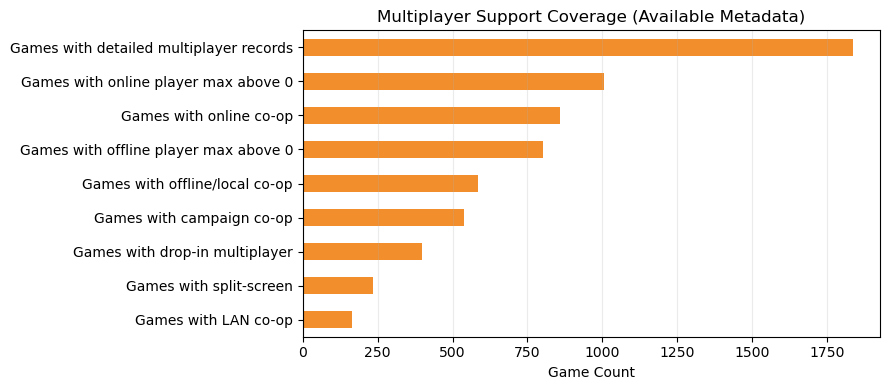

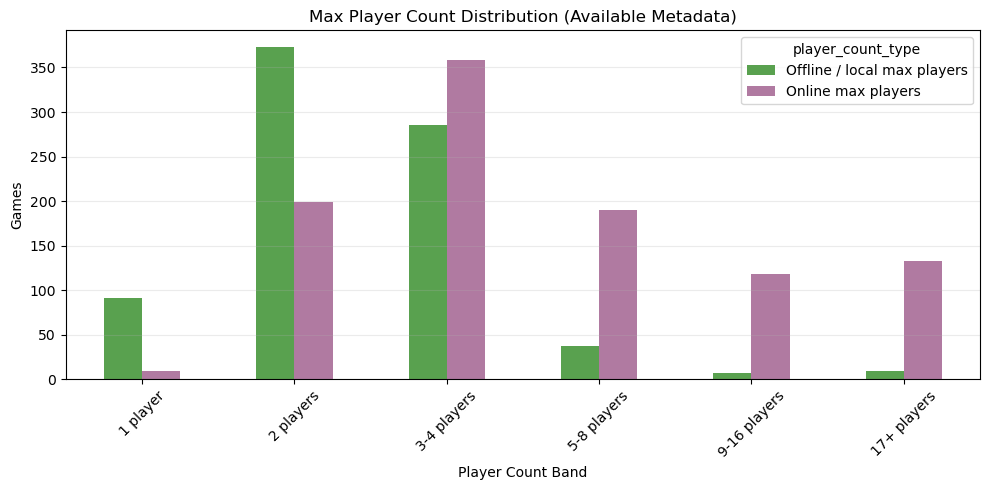

In [21]:
plot_barh(game_mode_distribution, 'game_mode', 'game_count', 'Games by Game Mode (Non-Exclusive)', top_n=len(game_mode_distribution), color='#4C78A8')

support_chart = multiplayer_support_coverage[
    ~multiplayer_support_coverage['metric'].isin(['Games with game mode labels'])
].copy()
plot_barh(support_chart, 'metric', 'game_count', 'Multiplayer Support Coverage (Available Metadata)', top_n=len(support_chart), color='#F28E2B')

if not player_count_distribution.empty:
    player_pivot = player_count_distribution.pivot_table(
        index='player_count_band',
        columns='player_count_type',
        values='game_count',
        aggfunc='sum',
        fill_value=0,
    )
    band_order = ['1 player', '2 players', '3-4 players', '5-8 players', '9-16 players', '17+ players']
    player_pivot = player_pivot.reindex([band for band in band_order if band in player_pivot.index])
    ax = player_pivot.plot(kind='bar', figsize=(10, 5), color=['#59A14F', '#B07AA1'])
    ax.set_title('Max Player Count Distribution (Available Metadata)')
    ax.set_xlabel('Player Count Band')
    ax.set_ylabel('Games')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()

# 9. Additional Descriptive Exploration

This section expands the descriptive pillar beyond catalog, platform, rating, company, and data-quality coverage. These analyses remain descriptive: they summarize what metadata exists and what the project sample looks like, without explaining rating differences or making recommendations.

## Gameplay Perspective and Playtime

Player perspective counts are non-exclusive. Time-to-beat records only describe games where IGDB has time-to-beat metadata; missing records mean unknown, not zero playtime.

,player_perspective,game_count,total_games,pct_of_games
0,Bird view / Isometric,2393,15000,15.95
1,Third person,2351,15000,15.67
2,Side view,2334,15000,15.56
3,First person,1992,15000,13.28
4,Text,851,15000,5.67
5,Virtual Reality,301,15000,2.01
6,Auditory,74,15000,0.49


,metric,game_count,total_games,pct_of_games
0,Games with time-to-beat record,2316,15000,15.44
1,Games with hastily estimate,1317,15000,8.78
2,Games with normally estimate,1961,15000,13.07
3,Games with completely estimate,1438,15000,9.59
4,Games with time-to-beat submission count,2316,15000,15.44


,playtime_band,game_count,median_normally_hours,p95_normally_hours,max_normally_hours
5,Under 5 hours,410,3.00,4.47,4.98
3,5-9 hours,471,7.00,9.14,9.86
0,10-19 hours,417,13.50,18.51,19.89
1,20-39 hours,315,25.94,37.94,39.67
2,40-79 hours,206,50.00,75.00,79.00
4,80+ hours,142,150.00,"3,237.50","277,430.50"


,game_id,name,hastily_hours,normally_hours,completely_hours,time_to_beat_submission_count,playtime_band
0,143228,Gorilla Tag,997.50,"277,430.50","20,629.50",6,80+ hours
1,144983,Rocket League Sideswipe,"73,266.50","99,999.00","53,272.00",2,80+ hours
2,139381,Voxiom.io,890.00,"78,678.00","57,886.00",1,80+ hours
3,17131,BeamNG.drive,"50,000.00","50,000.50","49,999.59",3,80+ hours
4,214414,Where Winds Meet,"20,015.20","25,107.75","25,256.00",7,80+ hours
5,294661,Content Warning,106.00,"21,614.00","216,228.00",3,80+ hours
6,33615,VRChat,877.00,"3,308.00","99,999.00",4,80+ hours
7,1912,Warface,NaN,"3,250.00",NaN,2,80+ hours
8,19698,Albion Online,1.00,"3,000.00","9,999.00",6,80+ hours
9,11642,Geometry Dash,"9,145.33","2,917.50","90,760.56",13,80+ hours


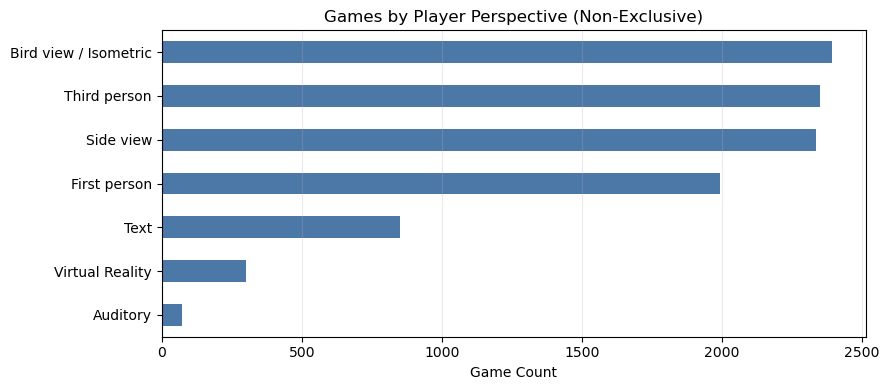

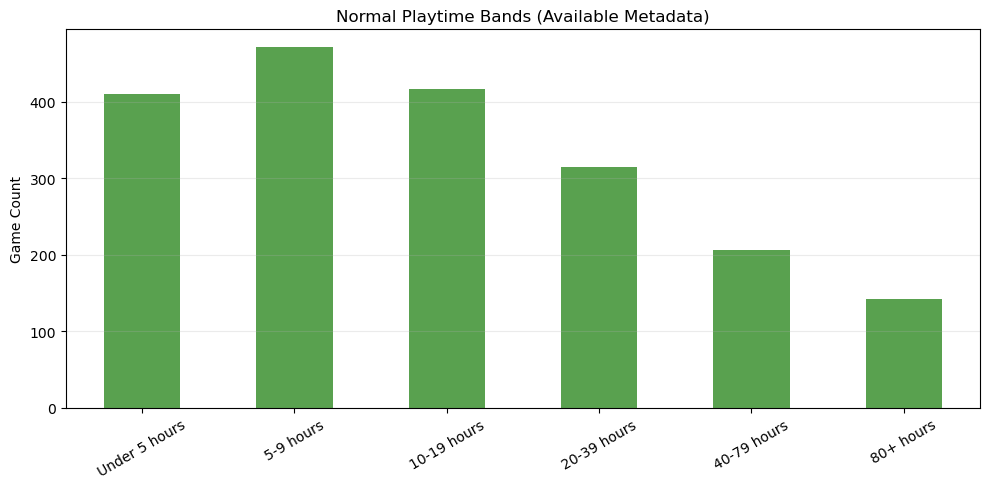

In [22]:
display_section(
    'Gameplay Perspective and Playtime',
    'Player perspective counts are non-exclusive. Time-to-beat records only describe games where IGDB has time-to-beat metadata; missing records mean unknown, not zero playtime.'
)

player_perspective_distribution = run_query('''
WITH total AS (
    SELECT COUNT(DISTINCT game_id) AS total_games
    FROM games
)
SELECT
    pp.name AS player_perspective,
    COUNT(DISTINCT gpp.game_id) AS game_count,
    total.total_games,
    ROUND(100.0 * COUNT(DISTINCT gpp.game_id) / total.total_games, 2) AS pct_of_games
FROM game_player_perspectives gpp
JOIN player_perspectives pp
    ON gpp.player_perspective_id = pp.player_perspective_id
CROSS JOIN total
GROUP BY pp.name, total.total_games
ORDER BY game_count DESC, pp.name;
''')

time_to_beat_coverage = run_query('''
WITH total AS (
    SELECT COUNT(DISTINCT game_id) AS total_games
    FROM games
), coverage AS (
    SELECT
        COUNT(DISTINCT game_id) AS games_with_time_to_beat,
        COUNT(DISTINCT CASE WHEN hastily IS NOT NULL AND hastily > 0 THEN game_id END) AS games_with_hastily,
        COUNT(DISTINCT CASE WHEN normally IS NOT NULL AND normally > 0 THEN game_id END) AS games_with_normally,
        COUNT(DISTINCT CASE WHEN completely IS NOT NULL AND completely > 0 THEN game_id END) AS games_with_completely,
        COUNT(DISTINCT CASE WHEN "count" IS NOT NULL AND "count" > 0 THEN game_id END) AS games_with_submission_count
    FROM game_time_to_beats
)
SELECT
    metric,
    game_count,
    total.total_games,
    ROUND(100.0 * game_count / total.total_games, 2) AS pct_of_games
FROM (
    SELECT 'Games with time-to-beat record' AS metric, games_with_time_to_beat AS game_count FROM coverage
    UNION ALL
    SELECT 'Games with hastily estimate', games_with_hastily FROM coverage
    UNION ALL
    SELECT 'Games with normally estimate', games_with_normally FROM coverage
    UNION ALL
    SELECT 'Games with completely estimate', games_with_completely FROM coverage
    UNION ALL
    SELECT 'Games with time-to-beat submission count', games_with_submission_count FROM coverage
) metrics
CROSS JOIN total;
''')

playtime_by_game = run_query('''
SELECT
    g.game_id,
    g.name,
    ROUND(gtb.hastily / 3600.0, 2) AS hastily_hours,
    ROUND(gtb.normally / 3600.0, 2) AS normally_hours,
    ROUND(gtb.completely / 3600.0, 2) AS completely_hours,
    gtb."count" AS time_to_beat_submission_count
FROM game_time_to_beats gtb
JOIN games g
    ON gtb.game_id = g.game_id
WHERE gtb.normally IS NOT NULL
  AND gtb.normally > 0
ORDER BY normally_hours DESC, g.name;
''')

playtime_band_order = {
    'Under 5 hours': 1,
    '5-9 hours': 2,
    '10-19 hours': 3,
    '20-39 hours': 4,
    '40-79 hours': 5,
    '80+ hours': 6,
}

def playtime_band(hours):
    if hours < 5:
        return 'Under 5 hours'
    if hours < 10:
        return '5-9 hours'
    if hours < 20:
        return '10-19 hours'
    if hours < 40:
        return '20-39 hours'
    if hours < 80:
        return '40-79 hours'
    return '80+ hours'

playtime_by_game['playtime_band'] = playtime_by_game['normally_hours'].apply(playtime_band)
playtime_by_game['band_order'] = playtime_by_game['playtime_band'].map(playtime_band_order)

playtime_band_distribution = (
    playtime_by_game
    .groupby(['playtime_band', 'band_order'], as_index=False)
    .agg(
        game_count=('game_id', 'nunique'),
        median_normally_hours=('normally_hours', 'median'),
        p95_normally_hours=('normally_hours', lambda values: values.quantile(0.95)),
        max_normally_hours=('normally_hours', 'max'),
    )
    .sort_values('band_order')
)
for col in ['median_normally_hours', 'p95_normally_hours', 'max_normally_hours']:
    playtime_band_distribution[col] = playtime_band_distribution[col].round(2)

playtime_outlier_candidates = (
    playtime_by_game[playtime_by_game['normally_hours'] >= 200]
    .sort_values('normally_hours', ascending=False)
    .drop(columns=['band_order'], errors='ignore')
)

tables_to_export.update({
    'player_perspective_distribution': player_perspective_distribution,
    'time_to_beat_coverage': time_to_beat_coverage,
    'playtime_by_game': playtime_by_game.drop(columns=['band_order'], errors='ignore'),
    'playtime_band_distribution': playtime_band_distribution.drop(columns=['band_order'], errors='ignore'),
    'playtime_outlier_candidates': playtime_outlier_candidates,
})

display(player_perspective_distribution)
display(time_to_beat_coverage)
display(playtime_band_distribution.drop(columns=['band_order'], errors='ignore'))
display(playtime_outlier_candidates.head(20))

plot_barh(player_perspective_distribution, 'player_perspective', 'game_count', 'Games by Player Perspective (Non-Exclusive)', top_n=len(player_perspective_distribution), color='#4C78A8')
if not playtime_band_distribution.empty:
    plot_bar(playtime_band_distribution, 'playtime_band', 'game_count', 'Normal Playtime Bands (Available Metadata)', color='#59A14F', rotation=30)

## Catalog Availability and Release Metadata

These tables describe where games have website, external-source, release-date precision, release-status, and region metadata. Counts are descriptive coverage checks, not platform availability claims.

,website_type,website_record_count,game_count,total_games,pct_of_games
0,Twitch,11921,11921,15000,79.47
1,Official Website,8822,8822,15000,58.81
2,Steam,8808,8808,15000,58.72
3,Twitter,4682,4682,15000,31.21
4,YouTube,3876,3875,15000,25.83
5,Wikipedia,3360,3360,15000,22.40
6,Facebook,3229,3229,15000,21.53
7,Discord,2697,2696,15000,17.97
8,Community Wiki,2613,2613,15000,17.42
9,Playstation,2570,2570,15000,17.13


,external_source,external_game_record_count,game_count,total_games,pct_of_games
0,Twitch,14446,14432,15000,96.21
1,Steam,9071,8848,15000,58.99
2,GiantBomb,6173,6061,15000,40.41
3,Playstation Store US,2560,2542,15000,16.95
4,Microsoft,3041,2513,15000,16.75
5,Amazon,13544,1631,15000,10.87
6,GOG,1546,1469,15000,9.79
7,Itchio,1343,1340,15000,8.93
8,Epic Games Store,2005,1227,15000,8.18
9,Apple,1078,920,15000,6.13


,date_format,release_date_record_count,game_count,total_games,pct_of_games
0,YYYYMMDD,42189,14615,15000,97.43
1,YYYY,577,444,15000,2.96
2,TBD,430,341,15000,2.27
3,YYYYMM,148,117,15000,0.78
4,YYYYQ4,39,28,15000,0.19
5,YYYYQ1,25,18,15000,0.12
6,YYYYQ3,22,16,15000,0.11
7,YYYYQ2,17,14,15000,0.09


,release_status,release_date_record_count,game_count,total_games,pct_of_games
0,Unknown release status,30145,10751,15000,71.67
1,Full Release,11746,4594,15000,30.63
2,Early Access,881,597,15000,3.98
3,Offline,215,90,15000,0.60
4,Beta,148,82,15000,0.55
5,Advanced Access,103,32,15000,0.21
6,Cancelled,68,52,15000,0.35
7,Next-Gen Optimization Patch Release,63,42,15000,0.28
8,Alpha,39,27,15000,0.18
9,Digital Compatibility Release,39,13,15000,0.09


,release_region,release_date_record_count,game_count,total_games,pct_of_games
0,worldwide,30625,13110,15000,87.40
1,north_america,5656,3355,15000,22.37
2,europe,3407,2228,15000,14.85
3,japan,2436,1597,15000,10.65
4,australia,786,464,15000,3.09
5,asia,187,116,15000,0.77
6,china,128,85,15000,0.57
7,korea,118,77,15000,0.51
8,brazil,72,64,15000,0.43
9,new_zealand,32,23,15000,0.15


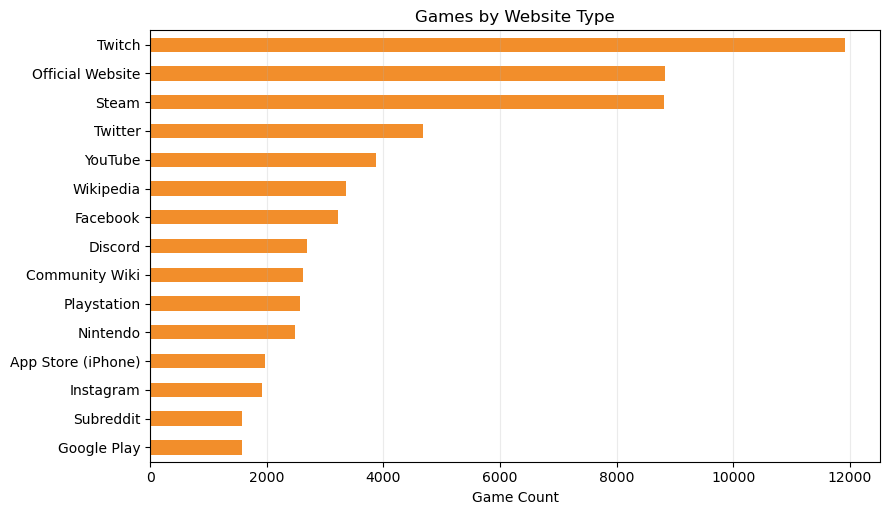

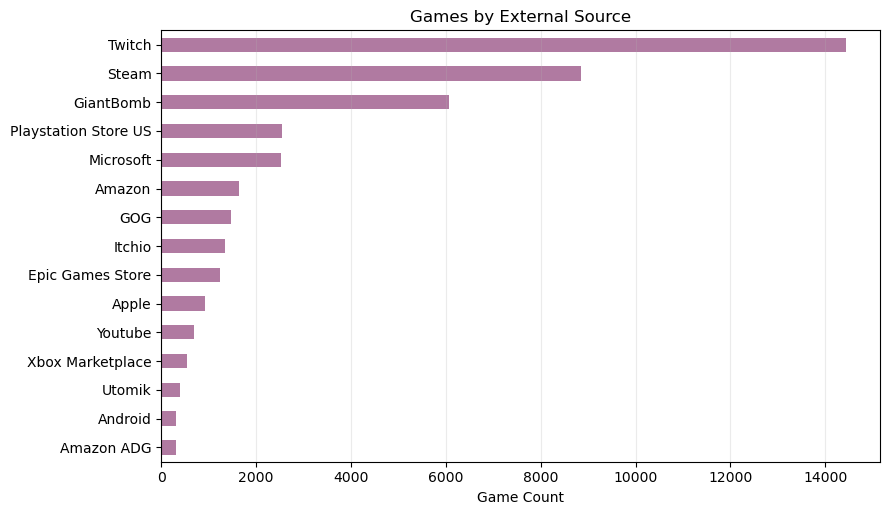

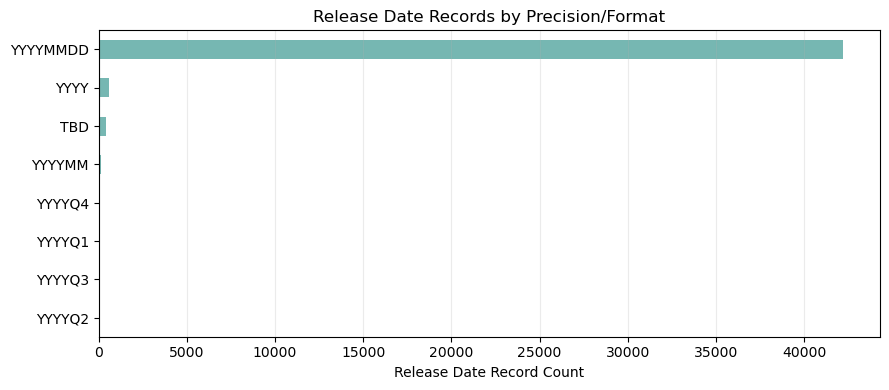

In [23]:
display_section(
    'Catalog Availability and Release Metadata',
    'These tables describe where games have website, external-source, release-date precision, release-status, and region metadata. Counts are descriptive coverage checks, not platform availability claims.'
)

website_type_coverage = run_query('''
WITH total AS (
    SELECT COUNT(DISTINCT game_id) AS total_games
    FROM games
)
SELECT
    COALESCE(wt.type_name, 'Unknown website type') AS website_type,
    COUNT(*) AS website_record_count,
    COUNT(DISTINCT w.game_id) AS game_count,
    total.total_games,
    ROUND(100.0 * COUNT(DISTINCT w.game_id) / total.total_games, 2) AS pct_of_games
FROM websites w
LEFT JOIN website_types wt
    ON w.website_type_id = wt.website_type_id
CROSS JOIN total
GROUP BY COALESCE(wt.type_name, 'Unknown website type'), total.total_games
ORDER BY game_count DESC, website_record_count DESC, website_type;
''')

external_source_coverage = run_query('''
WITH total AS (
    SELECT COUNT(DISTINCT game_id) AS total_games
    FROM games
)
SELECT
    COALESCE(egs.source_name, 'Unknown external source') AS external_source,
    COUNT(*) AS external_game_record_count,
    COUNT(DISTINCT eg.game_id) AS game_count,
    total.total_games,
    ROUND(100.0 * COUNT(DISTINCT eg.game_id) / total.total_games, 2) AS pct_of_games
FROM external_games eg
LEFT JOIN external_game_sources egs
    ON eg.external_game_source_id = egs.external_game_source_id
CROSS JOIN total
GROUP BY COALESCE(egs.source_name, 'Unknown external source'), total.total_games
ORDER BY game_count DESC, external_game_record_count DESC, external_source;
''')

release_date_format_coverage = run_query('''
WITH total AS (
    SELECT COUNT(DISTINCT game_id) AS total_games
    FROM games
)
SELECT
    COALESCE(df.format_name, 'Unknown date format') AS date_format,
    COUNT(*) AS release_date_record_count,
    COUNT(DISTINCT rd.game_id) AS game_count,
    total.total_games,
    ROUND(100.0 * COUNT(DISTINCT rd.game_id) / total.total_games, 2) AS pct_of_games
FROM release_dates rd
LEFT JOIN date_formats df
    ON rd.date_format_id = df.date_format_id
CROSS JOIN total
GROUP BY COALESCE(df.format_name, 'Unknown date format'), total.total_games
ORDER BY release_date_record_count DESC, date_format;
''')

release_date_status_coverage = run_query('''
WITH total AS (
    SELECT COUNT(DISTINCT game_id) AS total_games
    FROM games
)
SELECT
    COALESCE(rds.status_name, 'Unknown release status') AS release_status,
    COUNT(*) AS release_date_record_count,
    COUNT(DISTINCT rd.game_id) AS game_count,
    total.total_games,
    ROUND(100.0 * COUNT(DISTINCT rd.game_id) / total.total_games, 2) AS pct_of_games
FROM release_dates rd
LEFT JOIN release_date_statuses rds
    ON rd.release_date_status_id = rds.release_date_status_id
CROSS JOIN total
GROUP BY COALESCE(rds.status_name, 'Unknown release status'), total.total_games
ORDER BY release_date_record_count DESC, release_status;
''')

release_date_region_coverage = run_query('''
WITH total AS (
    SELECT COUNT(DISTINCT game_id) AS total_games
    FROM games
)
SELECT
    COALESCE(rdr.region_name, 'Unknown release region') AS release_region,
    COUNT(*) AS release_date_record_count,
    COUNT(DISTINCT rd.game_id) AS game_count,
    total.total_games,
    ROUND(100.0 * COUNT(DISTINCT rd.game_id) / total.total_games, 2) AS pct_of_games
FROM release_dates rd
LEFT JOIN release_date_regions rdr
    ON rd.release_date_region_id = rdr.release_date_region_id
CROSS JOIN total
GROUP BY COALESCE(rdr.region_name, 'Unknown release region'), total.total_games
ORDER BY release_date_record_count DESC, release_region;
''')

tables_to_export.update({
    'website_type_coverage': website_type_coverage,
    'external_source_coverage': external_source_coverage,
    'release_date_format_coverage': release_date_format_coverage,
    'release_date_status_coverage': release_date_status_coverage,
    'release_date_region_coverage': release_date_region_coverage,
})

display(website_type_coverage.head(25))
display(external_source_coverage.head(25))
display(release_date_format_coverage)
display(release_date_status_coverage)
display(release_date_region_coverage.head(25))

plot_barh(website_type_coverage, 'website_type', 'game_count', 'Games by Website Type', top_n=15, color='#F28E2B')
plot_barh(external_source_coverage, 'external_source', 'game_count', 'Games by External Source', top_n=15, color='#B07AA1')
plot_barh(release_date_format_coverage, 'date_format', 'release_date_record_count', 'Release Date Records by Precision/Format', top_n=len(release_date_format_coverage), color='#76B7B2')

## Text, Relationship-Volume Coverage, and Keyword Cleanup

These checks summarize summary/storyline length, relationship-table volume, and keyword values that may need cleanup before downstream search, filtering, or reporting.

,count,mean,std,min,25%,50%,75%,max
summary_length,"15,000.00",314.65,283.49,0.00,148.00,251.00,391.00,"4,718.00"
storyline_length,"15,000.00",130.26,441.62,0.00,0.00,0.00,0.00,"20,764.00"


,summary_length_band,game_count
0,Short summary,7021
1,Medium summary,6610
2,Long summary,933
3,Missing summary,436


,storyline_length_band,game_count
0,Missing storyline,11928
1,Medium storyline,1804
2,Long storyline,739
3,Short storyline,529


,game_id,name,genre_count,theme_count,keyword_count,platform_count,involved_company_count,game_mode_count,player_perspective_count,website_count,external_source_count,screenshot_count,metadata_relationship_count
0,1020,Grand Theft Auto V,3,4,207,5,4,3,2,14,61,18,321
1,2943,Scribblenauts Unlimited,4,1,213,5,3,1,1,7,6,12,253
2,74,Mass Effect 2,3,2,208,3,4,1,1,11,8,5,246
3,16,Fallout: New Vegas,2,6,196,3,4,1,2,13,11,7,245
4,538,BioShock Infinite,2,6,176,5,6,1,1,13,8,19,237
5,185249,Nightingale,2,4,192,1,1,3,2,10,4,13,232
6,21,BioShock 2,4,4,178,4,10,2,1,10,9,5,227
7,1082,Resident Evil 6,2,4,170,3,2,3,1,11,19,6,221
8,545,Call of Duty: Black Ops,1,6,154,4,4,4,1,12,21,10,217
9,1981,Saints Row IV,2,5,174,6,3,3,1,7,8,6,215


,metadata_richness_band,game_count,min_relationship_count,median_relationship_count,max_relationship_count
0,Lean relationship profile (<50 links),12895,3,19.00,49
1,Moderate relationship profile (50-99 links),1861,50,61.00,99
2,Rich relationship profile (100-149 links),196,100,114.00,149
3,Very rich relationship profile (150+ links),48,150,178.50,321


,keyword_review_category,keyword_count,total_game_mentions
0,Likely semantic term,3757,77159
1,Review platform/store term,1,1115
2,Review punctuation or compound term,9,127
3,Review term containing number,199,4128
4,Review very short term,6,595


,keyword_id,keyword_name,keyword_slug,game_count,keyword_review_category
3757,1158,steam,steam,1115,Review platform/store term
3758,2452,day/night cycle,day-slash-night-cycle,108,Review punctuation or compound term
3759,12109,best debut indie game: nominee - 2017 (the gam...,best-debut-indie-game-nominee-2017-the-game-aw...,5,Review punctuation or compound term
3760,14056,best fighting game: nominee - 2016 (the game a...,best-fighting-game-nominee-2016-the-game-awards,3,Review punctuation or compound term
3761,14059,best role playing game: nominee - 2016 (the ga...,best-role-playing-game-nominee-2016-the-game-a...,3,Review punctuation or compound term
3762,14086,games for impact award: nominee - 2016 (the ga...,games-for-impact-award-nominee-2016-the-game-a...,3,Review punctuation or compound term
3763,2012,breakout/arkanoid clone,breakout-slash-arkanoid-clone,2,Review punctuation or compound term
3764,14057,best fighting game: winner - 2016 (the game aw...,best-fighting-game-winner-2016-the-game-awards,1,Review punctuation or compound term
3765,12105,best performance: winner - 2017 (the game awards),best-performance-winner-2017-the-game-awards,1,Review punctuation or compound term
3766,12153,best sports/racing game: winner - 2017 (the ga...,best-sports-slash-racing-game-winner-2017-the-...,1,Review punctuation or compound term


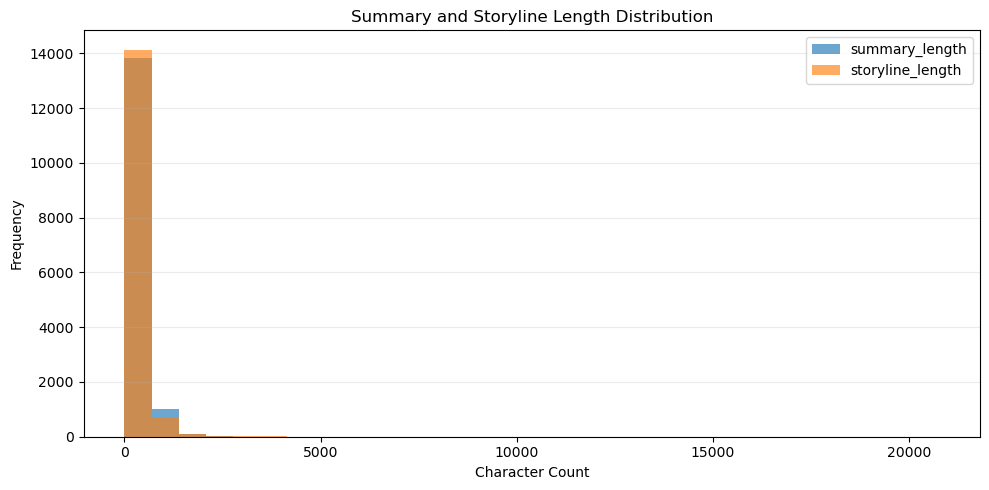

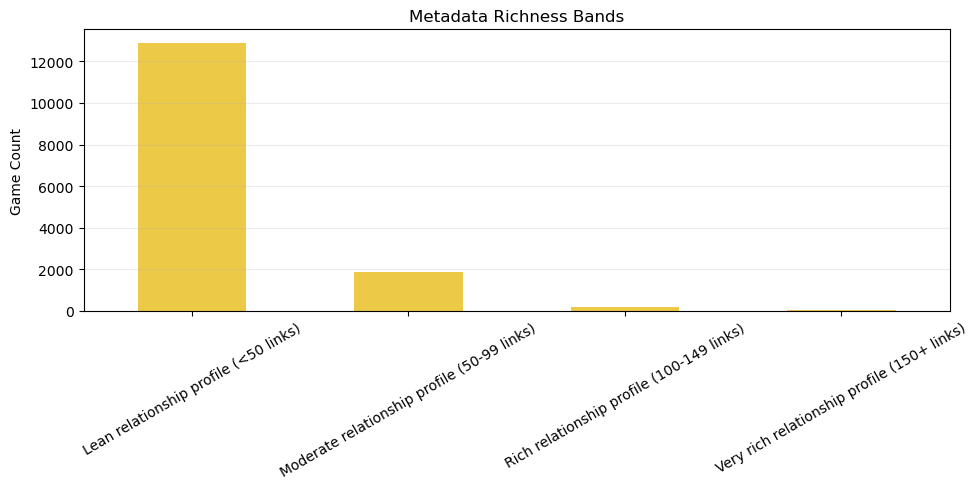

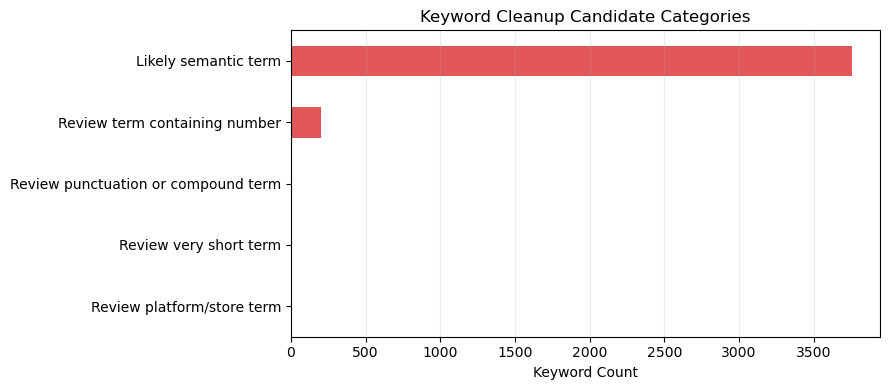

In [24]:
display_section(
    'Text, Relationship-Volume Coverage, and Keyword Cleanup',
    'These checks summarize summary/storyline length, relationship-table volume, and keyword values that may need cleanup before downstream search, filtering, or reporting.'
)

text_length_distribution = run_query('''
SELECT
    game_id,
    name,
    LENGTH(COALESCE(summary, '')) AS summary_length,
    LENGTH(COALESCE(storyline, '')) AS storyline_length,
    CASE
        WHEN summary IS NULL OR TRIM(summary) = '' THEN 'Missing summary'
        WHEN LENGTH(summary) < 250 THEN 'Short summary'
        WHEN LENGTH(summary) < 750 THEN 'Medium summary'
        ELSE 'Long summary'
    END AS summary_length_band,
    CASE
        WHEN storyline IS NULL OR TRIM(storyline) = '' THEN 'Missing storyline'
        WHEN LENGTH(storyline) < 250 THEN 'Short storyline'
        WHEN LENGTH(storyline) < 750 THEN 'Medium storyline'
        ELSE 'Long storyline'
    END AS storyline_length_band
FROM games
ORDER BY summary_length DESC, storyline_length DESC, name;
''')

relationship_counts_per_game = run_query('''
WITH genre_counts AS (
    SELECT game_id, COUNT(*) AS genre_count FROM game_genres GROUP BY game_id
), theme_counts AS (
    SELECT game_id, COUNT(*) AS theme_count FROM game_themes GROUP BY game_id
), keyword_counts AS (
    SELECT game_id, COUNT(*) AS keyword_count FROM game_keywords GROUP BY game_id
), platform_counts AS (
    SELECT game_id, COUNT(*) AS platform_count FROM game_platforms GROUP BY game_id
), company_counts AS (
    SELECT game_id, COUNT(*) AS involved_company_count FROM involved_companies GROUP BY game_id
), mode_counts AS (
    SELECT game_id, COUNT(*) AS game_mode_count FROM game_modes_bridge GROUP BY game_id
), perspective_counts AS (
    SELECT game_id, COUNT(*) AS player_perspective_count FROM game_player_perspectives GROUP BY game_id
), website_counts AS (
    SELECT game_id, COUNT(*) AS website_count FROM websites GROUP BY game_id
), external_counts AS (
    SELECT game_id, COUNT(*) AS external_source_count FROM external_games GROUP BY game_id
), screenshot_counts AS (
    SELECT game_id, COUNT(*) AS screenshot_count FROM screenshots GROUP BY game_id
)
SELECT
    g.game_id,
    g.name,
    COALESCE(gc.genre_count, 0) AS genre_count,
    COALESCE(tc.theme_count, 0) AS theme_count,
    COALESCE(kc.keyword_count, 0) AS keyword_count,
    COALESCE(pc.platform_count, 0) AS platform_count,
    COALESCE(cc.involved_company_count, 0) AS involved_company_count,
    COALESCE(mc.game_mode_count, 0) AS game_mode_count,
    COALESCE(ppc.player_perspective_count, 0) AS player_perspective_count,
    COALESCE(wc.website_count, 0) AS website_count,
    COALESCE(ec.external_source_count, 0) AS external_source_count,
    COALESCE(sc.screenshot_count, 0) AS screenshot_count,
    COALESCE(gc.genre_count, 0) + COALESCE(tc.theme_count, 0) + COALESCE(kc.keyword_count, 0)
        + COALESCE(pc.platform_count, 0) + COALESCE(cc.involved_company_count, 0)
        + COALESCE(mc.game_mode_count, 0) + COALESCE(ppc.player_perspective_count, 0)
        + COALESCE(wc.website_count, 0) + COALESCE(ec.external_source_count, 0)
        + COALESCE(sc.screenshot_count, 0) AS metadata_relationship_count
FROM games g
LEFT JOIN genre_counts gc ON g.game_id = gc.game_id
LEFT JOIN theme_counts tc ON g.game_id = tc.game_id
LEFT JOIN keyword_counts kc ON g.game_id = kc.game_id
LEFT JOIN platform_counts pc ON g.game_id = pc.game_id
LEFT JOIN company_counts cc ON g.game_id = cc.game_id
LEFT JOIN mode_counts mc ON g.game_id = mc.game_id
LEFT JOIN perspective_counts ppc ON g.game_id = ppc.game_id
LEFT JOIN website_counts wc ON g.game_id = wc.game_id
LEFT JOIN external_counts ec ON g.game_id = ec.game_id
LEFT JOIN screenshot_counts sc ON g.game_id = sc.game_id
ORDER BY metadata_relationship_count DESC, g.name;
''')

metadata_richness_by_game = run_query('''
WITH genre_counts AS (
    SELECT game_id, COUNT(*) AS genre_count FROM game_genres GROUP BY game_id
), theme_counts AS (
    SELECT game_id, COUNT(*) AS theme_count FROM game_themes GROUP BY game_id
), keyword_counts AS (
    SELECT game_id, COUNT(*) AS keyword_count FROM game_keywords GROUP BY game_id
), platform_counts AS (
    SELECT game_id, COUNT(*) AS platform_count FROM game_platforms GROUP BY game_id
), company_counts AS (
    SELECT game_id, COUNT(*) AS involved_company_count FROM involved_companies GROUP BY game_id
), mode_counts AS (
    SELECT game_id, COUNT(*) AS game_mode_count FROM game_modes_bridge GROUP BY game_id
), perspective_counts AS (
    SELECT game_id, COUNT(*) AS player_perspective_count FROM game_player_perspectives GROUP BY game_id
), website_counts AS (
    SELECT game_id, COUNT(*) AS website_count FROM websites GROUP BY game_id
), external_counts AS (
    SELECT game_id, COUNT(*) AS external_source_count FROM external_games GROUP BY game_id
), screenshot_counts AS (
    SELECT game_id, COUNT(*) AS screenshot_count FROM screenshots GROUP BY game_id
), time_to_beat_counts AS (
    SELECT game_id, COUNT(*) AS time_to_beat_count FROM game_time_to_beats GROUP BY game_id
)
SELECT
    g.game_id,
    g.name,
    CASE WHEN g.summary IS NOT NULL AND TRIM(g.summary) != '' THEN 1 ELSE 0 END AS has_summary,
    CASE WHEN g.storyline IS NOT NULL AND TRIM(g.storyline) != '' THEN 1 ELSE 0 END AS has_storyline,
    CASE WHEN g.cover_id IS NOT NULL THEN 1 ELSE 0 END AS has_cover_reference,
    CASE WHEN COALESCE(gc.genre_count, 0) > 0 THEN 1 ELSE 0 END AS has_genre,
    CASE WHEN COALESCE(tc.theme_count, 0) > 0 THEN 1 ELSE 0 END AS has_theme,
    CASE WHEN COALESCE(kc.keyword_count, 0) > 0 THEN 1 ELSE 0 END AS has_keyword,
    CASE WHEN COALESCE(pc.platform_count, 0) > 0 THEN 1 ELSE 0 END AS has_platform,
    CASE WHEN COALESCE(cc.involved_company_count, 0) > 0 THEN 1 ELSE 0 END AS has_company,
    CASE WHEN COALESCE(mc.game_mode_count, 0) > 0 THEN 1 ELSE 0 END AS has_game_mode,
    CASE WHEN COALESCE(ppc.player_perspective_count, 0) > 0 THEN 1 ELSE 0 END AS has_player_perspective,
    CASE WHEN COALESCE(wc.website_count, 0) > 0 THEN 1 ELSE 0 END AS has_website,
    CASE WHEN COALESCE(ec.external_source_count, 0) > 0 THEN 1 ELSE 0 END AS has_external_source,
    CASE WHEN COALESCE(sc.screenshot_count, 0) > 0 THEN 1 ELSE 0 END AS has_screenshot,
    CASE WHEN COALESCE(tbc.time_to_beat_count, 0) > 0 THEN 1 ELSE 0 END AS has_time_to_beat
FROM games g
LEFT JOIN genre_counts gc ON g.game_id = gc.game_id
LEFT JOIN theme_counts tc ON g.game_id = tc.game_id
LEFT JOIN keyword_counts kc ON g.game_id = kc.game_id
LEFT JOIN platform_counts pc ON g.game_id = pc.game_id
LEFT JOIN company_counts cc ON g.game_id = cc.game_id
LEFT JOIN mode_counts mc ON g.game_id = mc.game_id
LEFT JOIN perspective_counts ppc ON g.game_id = ppc.game_id
LEFT JOIN website_counts wc ON g.game_id = wc.game_id
LEFT JOIN external_counts ec ON g.game_id = ec.game_id
LEFT JOIN screenshot_counts sc ON g.game_id = sc.game_id
LEFT JOIN time_to_beat_counts tbc ON g.game_id = tbc.game_id;
''')

richness_signal_cols = [col for col in metadata_richness_by_game.columns if col.startswith('has_')]
metadata_richness_by_game['metadata_signal_score'] = metadata_richness_by_game[richness_signal_cols].sum(axis=1)
metadata_richness_by_game = metadata_richness_by_game.merge(
    relationship_counts_per_game[['game_id', 'metadata_relationship_count']],
    on='game_id',
    how='left',
)
metadata_richness_by_game['metadata_relationship_count'] = metadata_richness_by_game['metadata_relationship_count'].fillna(0).astype(int)

def metadata_richness_band(relationship_count):
    if relationship_count < 50:
        return 'Lean relationship profile (<50 links)'
    if relationship_count < 100:
        return 'Moderate relationship profile (50-99 links)'
    if relationship_count < 150:
        return 'Rich relationship profile (100-149 links)'
    return 'Very rich relationship profile (150+ links)'

metadata_richness_by_game['metadata_richness_score'] = metadata_richness_by_game['metadata_relationship_count']
metadata_richness_by_game['metadata_richness_band'] = metadata_richness_by_game['metadata_relationship_count'].apply(metadata_richness_band)
metadata_band_order = [
    'Lean relationship profile (<50 links)',
    'Moderate relationship profile (50-99 links)',
    'Rich relationship profile (100-149 links)',
    'Very rich relationship profile (150+ links)',
]
metadata_richness_bands = (
    metadata_richness_by_game
    .groupby('metadata_richness_band', as_index=False)
    .agg(
        game_count=('game_id', 'nunique'),
        min_relationship_count=('metadata_relationship_count', 'min'),
        median_relationship_count=('metadata_relationship_count', 'median'),
        max_relationship_count=('metadata_relationship_count', 'max'),
    )
)
metadata_richness_bands['median_relationship_count'] = metadata_richness_bands['median_relationship_count'].round(2)
metadata_richness_bands['band_order'] = metadata_richness_bands['metadata_richness_band'].map({band: i for i, band in enumerate(metadata_band_order, start=1)})
metadata_richness_bands = metadata_richness_bands.sort_values('band_order')

keyword_cleanup_candidates = run_query('''
SELECT
    kw.keyword_id,
    kw.name AS keyword_name,
    kw.slug AS keyword_slug,
    COUNT(DISTINCT gk.game_id) AS game_count,
    CASE
        WHEN LENGTH(TRIM(kw.name)) <= 2 THEN 'Review very short term'
        WHEN LOWER(kw.name) IN ('steam', 'playstation', 'xbox', 'windows', 'linux', 'mac', 'nintendo', 'switch', 'pc') THEN 'Review platform/store term'
        WHEN kw.name LIKE '%,%' OR kw.name LIKE '%/%' OR kw.name LIKE '%:%' THEN 'Review punctuation or compound term'
        WHEN kw.name GLOB '*[0-9]*' THEN 'Review term containing number'
        ELSE 'Likely semantic term'
    END AS keyword_review_category
FROM game_keywords gk
JOIN keywords kw
    ON gk.keyword_id = kw.keyword_id
GROUP BY kw.keyword_id, kw.name, kw.slug
ORDER BY keyword_review_category, game_count DESC, keyword_name;
''')

keyword_cleanup_summary = (
    keyword_cleanup_candidates
    .groupby('keyword_review_category', as_index=False)
    .agg(keyword_count=('keyword_name', 'count'), total_game_mentions=('game_count', 'sum'))
    .sort_values(['keyword_review_category'])
)

tables_to_export.update({
    'text_length_distribution': text_length_distribution,
    'relationship_counts_per_game': relationship_counts_per_game,
    'metadata_richness_by_game': metadata_richness_by_game,
    'metadata_richness_bands': metadata_richness_bands.drop(columns=['band_order'], errors='ignore'),
    'keyword_cleanup_candidates': keyword_cleanup_candidates,
    'keyword_cleanup_summary': keyword_cleanup_summary,
})

display(text_length_distribution[['summary_length', 'storyline_length']].describe().T)
display(text_length_distribution['summary_length_band'].value_counts().rename_axis('summary_length_band').reset_index(name='game_count'))
display(text_length_distribution['storyline_length_band'].value_counts().rename_axis('storyline_length_band').reset_index(name='game_count'))
display(relationship_counts_per_game.head(20))
display(metadata_richness_bands.drop(columns=['band_order'], errors='ignore'))
display(keyword_cleanup_summary)
display(keyword_cleanup_candidates[keyword_cleanup_candidates['keyword_review_category'] != 'Likely semantic term'].head(50))

if not text_length_distribution.empty:
    ax = text_length_distribution[['summary_length', 'storyline_length']].plot.hist(bins=30, alpha=0.65, figsize=(10, 5))
    ax.set_title('Summary and Storyline Length Distribution')
    ax.set_xlabel('Character Count')
    ax.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()

plot_bar(metadata_richness_bands, 'metadata_richness_band', 'game_count', 'Metadata Relationship-Volume Bands', color='#EDC948', rotation=30)
plot_barh(keyword_cleanup_summary, 'keyword_review_category', 'keyword_count', 'Keyword Cleanup Candidate Categories', top_n=len(keyword_cleanup_summary), color='#E15759')

## Media Readiness

These tables describe cover and screenshot availability for dashboards, reports, and later application UI work.

,metric,game_count,total_games,pct_of_games
0,Games with cover,14446,15000,96.31
1,Games with screenshot,13714,15000,91.43
2,Games with cover and screenshot,13395,15000,89.30
3,Games with no cover or screenshot,235,15000,1.57


,screenshot_count_band,game_count
0,0 screenshots,1286
1,1 screenshot,665
2,2-3 screenshots,1568
3,4-6 screenshots,7443
4,7+ screenshots,4038


,image_type,image_record_count,records_with_dimensions,records_with_url,pct_with_dimensions,pct_with_url
0,Cover,14446,14441,14446,99.97,100.00
1,Screenshot,83764,83719,83764,99.95,100.00


,game_id,name,cover_count,covers_with_dimensions,covers_with_url,screenshot_count,screenshots_with_dimensions,screenshots_with_url
0,372232,Lucky Pikinini: Advanced Killer Cyborg,1,1,1,55,55,55
1,310797,Ports of Call Deluxe 3D 2024,1,1,1,44,44,44
2,144087,Wanted Raccoon,1,1,1,39,39,39
3,190194,Aussie Clowns At War,1,1,1,37,37,37
4,219679,Zad Maldan My Bloody Sacrifice,1,1,1,36,36,36
5,132355,Escape From Violet Institute,1,1,1,35,35,35
6,188228,Age of History II,1,1,1,34,34,34
7,152604,Car Mechanic Simulator 2021,1,1,1,32,32,32
8,138563,Nightmare Puppeteer,1,1,1,30,30,30
9,187697,Wars and Roses,1,1,1,29,29,29


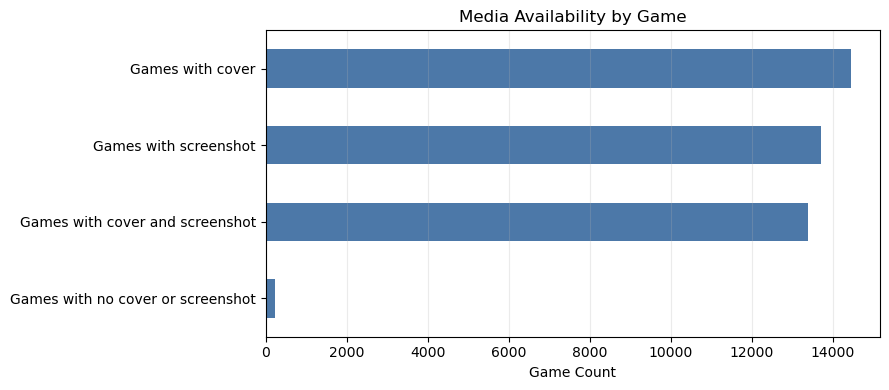

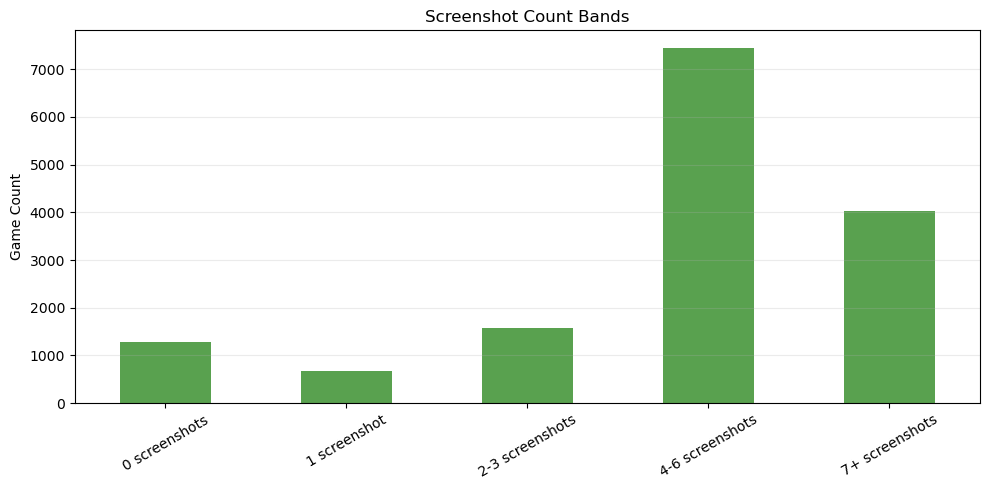

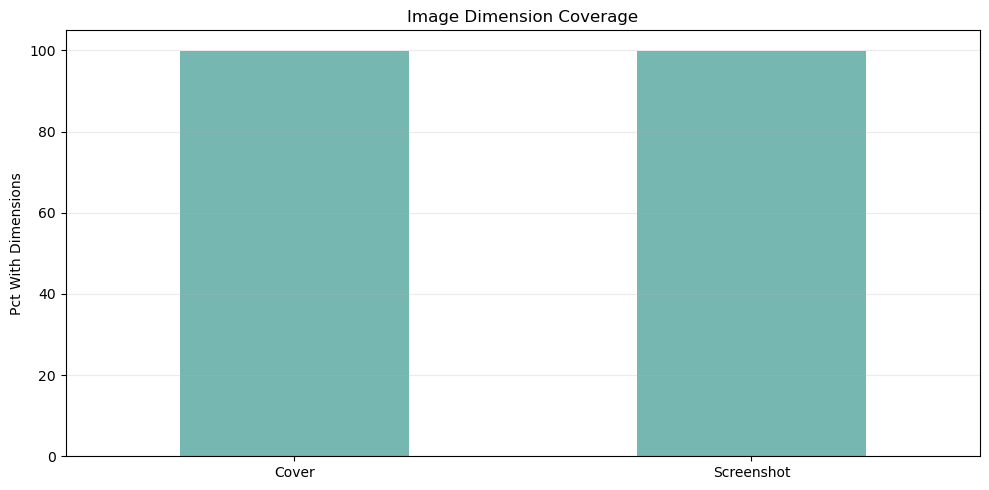

In [25]:
display_section(
    'Media Readiness',
    'These tables describe cover and screenshot availability for dashboards, reports, and later application UI work.'
)

media_by_game = run_query('''
WITH cover_counts AS (
    SELECT
        game_id,
        COUNT(*) AS cover_count,
        SUM(CASE WHEN width IS NOT NULL AND height IS NOT NULL THEN 1 ELSE 0 END) AS covers_with_dimensions,
        SUM(CASE WHEN url IS NOT NULL AND TRIM(url) != '' THEN 1 ELSE 0 END) AS covers_with_url
    FROM covers
    GROUP BY game_id
), screenshot_counts AS (
    SELECT
        game_id,
        COUNT(*) AS screenshot_count,
        SUM(CASE WHEN width IS NOT NULL AND height IS NOT NULL THEN 1 ELSE 0 END) AS screenshots_with_dimensions,
        SUM(CASE WHEN url IS NOT NULL AND TRIM(url) != '' THEN 1 ELSE 0 END) AS screenshots_with_url
    FROM screenshots
    GROUP BY game_id
)
SELECT
    g.game_id,
    g.name,
    COALESCE(cc.cover_count, 0) AS cover_count,
    COALESCE(cc.covers_with_dimensions, 0) AS covers_with_dimensions,
    COALESCE(cc.covers_with_url, 0) AS covers_with_url,
    COALESCE(sc.screenshot_count, 0) AS screenshot_count,
    COALESCE(sc.screenshots_with_dimensions, 0) AS screenshots_with_dimensions,
    COALESCE(sc.screenshots_with_url, 0) AS screenshots_with_url
FROM games g
LEFT JOIN cover_counts cc ON g.game_id = cc.game_id
LEFT JOIN screenshot_counts sc ON g.game_id = sc.game_id
ORDER BY screenshot_count DESC, cover_count DESC, g.name;
''')

total_games_for_media = int(kpi_snapshot.loc[kpi_snapshot['kpi'] == 'Total Games', 'value'].iloc[0])
media_availability_summary = pd.DataFrame([
    {'metric': 'Games with cover', 'game_count': int((media_by_game['cover_count'] > 0).sum())},
    {'metric': 'Games with screenshot', 'game_count': int((media_by_game['screenshot_count'] > 0).sum())},
    {'metric': 'Games with cover and screenshot', 'game_count': int(((media_by_game['cover_count'] > 0) & (media_by_game['screenshot_count'] > 0)).sum())},
    {'metric': 'Games with no cover or screenshot', 'game_count': int(((media_by_game['cover_count'] == 0) & (media_by_game['screenshot_count'] == 0)).sum())},
])
media_availability_summary['total_games'] = total_games_for_media
media_availability_summary['pct_of_games'] = (100 * media_availability_summary['game_count'] / total_games_for_media).round(2)

def screenshot_count_band(count):
    if count == 0:
        return '0 screenshots'
    if count == 1:
        return '1 screenshot'
    if count <= 3:
        return '2-3 screenshots'
    if count <= 6:
        return '4-6 screenshots'
    return '7+ screenshots'

screenshot_count_order = {
    '0 screenshots': 1,
    '1 screenshot': 2,
    '2-3 screenshots': 3,
    '4-6 screenshots': 4,
    '7+ screenshots': 5,
}
screenshot_count_distribution = media_by_game.copy()
screenshot_count_distribution['screenshot_count_band'] = screenshot_count_distribution['screenshot_count'].apply(screenshot_count_band)
screenshot_count_distribution = (
    screenshot_count_distribution
    .groupby('screenshot_count_band', as_index=False)
    .size()
    .rename(columns={'size': 'game_count'})
)
screenshot_count_distribution['sort_order'] = screenshot_count_distribution['screenshot_count_band'].map(screenshot_count_order)
screenshot_count_distribution = screenshot_count_distribution.sort_values('sort_order')

cover_records = int(media_by_game['cover_count'].sum())
screenshot_records = int(media_by_game['screenshot_count'].sum())
image_dimension_coverage = pd.DataFrame([
    {
        'image_type': 'Cover',
        'image_record_count': cover_records,
        'records_with_dimensions': int(media_by_game['covers_with_dimensions'].sum()),
        'records_with_url': int(media_by_game['covers_with_url'].sum()),
    },
    {
        'image_type': 'Screenshot',
        'image_record_count': screenshot_records,
        'records_with_dimensions': int(media_by_game['screenshots_with_dimensions'].sum()),
        'records_with_url': int(media_by_game['screenshots_with_url'].sum()),
    },
])
image_dimension_coverage['pct_with_dimensions'] = image_dimension_coverage.apply(
    lambda row: round(100 * row['records_with_dimensions'] / row['image_record_count'], 2) if row['image_record_count'] else 0,
    axis=1,
)
image_dimension_coverage['pct_with_url'] = image_dimension_coverage.apply(
    lambda row: round(100 * row['records_with_url'] / row['image_record_count'], 2) if row['image_record_count'] else 0,
    axis=1,
)

tables_to_export.update({
    'media_by_game': media_by_game,
    'media_availability_summary': media_availability_summary,
    'screenshot_count_distribution': screenshot_count_distribution.drop(columns=['sort_order'], errors='ignore'),
    'image_dimension_coverage': image_dimension_coverage,
})

display(media_availability_summary)
display(screenshot_count_distribution.drop(columns=['sort_order'], errors='ignore'))
display(image_dimension_coverage)
display(media_by_game.head(20))

plot_barh(media_availability_summary, 'metric', 'game_count', 'Media Availability by Game', top_n=len(media_availability_summary), color='#4C78A8')
plot_bar(screenshot_count_distribution, 'screenshot_count_band', 'game_count', 'Screenshot Count Bands', color='#59A14F', rotation=30)
plot_bar(image_dimension_coverage, 'image_type', 'pct_with_dimensions', 'Image Dimension Coverage', color='#76B7B2', rotation=0)

# 10. Auto-Generated Takeaway Prompts

Run the next cell after executing the notebook. Use the generated prompts as a starting point for dashboard annotations or report text, then revise them based on the actual charts.

In [26]:
total_games_value = int(kpi_snapshot.loc[kpi_snapshot['kpi'] == 'Total Games', 'value'].iloc[0])
top_genre_text = top_genres.iloc[0]['genre_name'] if not top_genres.empty else 'N/A'
top_platform_text = top_platforms.iloc[0]['platform_name'] if not top_platforms.empty else 'N/A'
rating_coverage_value = kpi_snapshot.loc[kpi_snapshot['kpi'] == 'Games With Total Rating', 'pct_of_games'].iloc[0]
summary_coverage_value = kpi_snapshot.loc[kpi_snapshot['kpi'] == 'Games With Summaries', 'pct_of_games'].iloc[0]
top_perspective_text = player_perspective_distribution.iloc[0]['player_perspective'] if 'player_perspective_distribution' in globals() and not player_perspective_distribution.empty else 'N/A'
time_to_beat_coverage_value = time_to_beat_coverage.loc[time_to_beat_coverage['metric'] == 'Games with time-to-beat record', 'pct_of_games'].iloc[0] if 'time_to_beat_coverage' in globals() and not time_to_beat_coverage.empty else 'N/A'
cover_coverage_value = media_availability_summary.loc[media_availability_summary['metric'] == 'Games with cover', 'pct_of_games'].iloc[0] if 'media_availability_summary' in globals() and not media_availability_summary.empty else 'N/A'
top_metadata_band_text = metadata_richness_bands.sort_values('game_count', ascending=False).iloc[0]['metadata_richness_band'] if 'metadata_richness_bands' in globals() and not metadata_richness_bands.empty else 'N/A'

def format_pct(value):
    try:
        return f'{float(value):.2f}%'
    except (TypeError, ValueError):
        return 'N/A'

takeaway_text = f'''
- The current project sample contains **{total_games_value:,} games**.
- The most represented genre in this sample is **{top_genre_text}**.
- The most represented platform in this sample is **{top_platform_text}**.
- The most represented player perspective is **{top_perspective_text}**.
- **{format_pct(rating_coverage_value)}** of games have `total_rating` available in this sample.
- **{format_pct(summary_coverage_value)}** of games have summary text available in this sample.
- **{format_pct(time_to_beat_coverage_value)}** of games have time-to-beat records in this sample.
- **{format_pct(cover_coverage_value)}** of games have cover records in this sample.
- The largest relationship-volume band is **{top_metadata_band_text}**.
- These takeaways describe the extracted project sample only, not the full IGDB catalog.
'''

display(Markdown(takeaway_text))


- The current project sample contains **15,000 games**.
- The most represented genre in this sample is **Indie**.
- The most represented platform in this sample is **PC (Microsoft Windows)**.
- The most represented player perspective is **Bird view / Isometric**.
- **41.85%** of games have `total_rating` available in this sample.
- **97.09%** of games have summary text available in this sample.
- **15.44%** of games have time-to-beat records in this sample.
- **96.31%** of games have cover records in this sample.
- The largest relationship-volume band is **Lean relationship profile (<50 links)**.
- These takeaways describe the extracted project sample only, not the full IGDB catalog.


# Additional Descriptive Areas Covered

The notebook now covers the expanded descriptive areas from the plan, while staying inside the descriptive pillar:

## Gameplay and Experience

- Game modes and multiplayer support.
- Player perspectives such as first-person, third-person, side view, and bird view.
- Time-to-beat coverage and normal playtime bands for available records.

## Catalog and Availability

- Website type coverage.
- External game source coverage.
- Release-date precision, release-status, and release-region coverage.

## Metadata and Text Readiness

- Summary/storyline length distributions.
- Number of genres, themes, keywords, platforms, and companies per game.
- Relationship-volume bands for sparse versus high-link-volume game profiles.
- Keyword cleanup candidate categories.

## Media and Presentation

- Games with covers and screenshots.
- Screenshot count per game.
- Image dimension coverage for UI consistency.

## Scope Guardrail

Avoid turning this descriptive notebook into diagnostic analysis. Questions like which genres perform best, why ratings differ, hidden-gem identification, or what games to recommend should stay in later pillars.

# 11. Optional Export

This cell exports the notebook's descriptive result tables to `data/analytics/descriptive/`. These CSVs can later feed a final Python script or Streamlit dashboard.

In [27]:
EXPORT_TABLES = True

if EXPORT_TABLES:
    exported_files = []
    for table_name, df in tables_to_export.items():
        output_path = OUTPUT_DIR / f'{table_name}.csv'
        df.to_csv(output_path, index=False)
        exported_files.append(str(output_path.relative_to(ROOT_DIR)))
    display(pd.DataFrame({'exported_file': exported_files}))
else:
    print('CSV export skipped. Set EXPORT_TABLES = True to export descriptive outputs.')

,exported_file
0,data\analytics\descriptive\database_table_row_...
1,data\analytics\descriptive\database_status.csv
2,data\analytics\descriptive\kpi_snapshot.csv
3,data\analytics\descriptive\top_genres.csv
4,data\analytics\descriptive\top_themes.csv
5,data\analytics\descriptive\top_keywords.csv
6,data\analytics\descriptive\game_type_breakdown...
7,data\analytics\descriptive\game_status_breakdo...
8,data\analytics\descriptive\top_platforms.csv
9,data\analytics\descriptive\platform_family_dis...


# 12. Close Database Connection

Run this at the end of the notebook session.

In [28]:
conn.close()
print('Database connection closed.')

Database connection closed.
